# Step 6 Analysis: PC vs LiNGAM Comparison

Analysis of Shapley values from the experimental pipeline for **mixed_no_conf_f50_s1000_p50** dataset with **LGBM** model.

This notebook explores:
- **Causal feature filtering**: Analysis focuses on features appearing in the discovered causal DAGs (PC or LiNGAM)
- **Consistent feature set**: ALL analyses use the SAME top 10 features (based on Scratch importance of causal features)
- PC vs LiNGAM comparison for these canonical top 10 features
- SHAP value distributions across methods
- Method agreement and correlations
- Detailed feature-level analysis

**Key Differences from Standard Analysis**: 
1. Rather than selecting top features purely by importance, we filter to features that appear in the causal graph and are Y-reachable
2. We define ONE canonical set of top 10 features (based on Scratch importance) and use this SAME set for ALL comparisons
3. This ensures we're comparing how different methods rank the SAME features, not comparing different feature sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
from PIL import Image

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
BASE_DIR = Path('/Users/juanrios/Documents/master_thesis')
EXPLAINABILITY_DIR = BASE_DIR / 'data' / 'explainability'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
SYNTHETIC_DIR = BASE_DIR / 'data' / 'synthetic'
CAUSAL_DIR = BASE_DIR / 'data'  / 'causal'

# Configuration
DATASET = 'mixed_no_conf_f50_s1000_p50'
MODEL = 'lgbm'

print(f"✓ Dataset: {DATASET}")
print(f"✓ Model: {MODEL}")

✓ Dataset: mixed_no_conf_f50_s1000_p50
✓ Model: lgbm


In [2]:

from typing import Dict, List, Tuple
def filter_adjacency_to_sink_reachable(
    adjacency_matrix: np.ndarray,
    feature_names: List[str],
    sink_name: str
) -> Tuple[np.ndarray, List[str], List[int], Dict]:
    """Filter adjacency matrix by zeroing out edges not reachable from sink.
    
    Uses backward BFS from sink node to identify all reachable nodes,
    then zeros out edges that are NOT between reachable nodes.
    Maintains same matrix size and feature order for data compatibility.
    
    Parameters
    ----------
    adjacency_matrix : np.ndarray
        Adjacency matrix where adj[i,j] != 0 means feature i causes feature j
    feature_names : list
        List of all feature names including sink
    sink_name : str
        Name of the sink/target node
    
    Returns
    -------
    filtered_adjacency : np.ndarray
        Adjacency matrix with irrelevant edges zeroed (same size as input)
    feature_names : list
        Same feature names as input (unchanged)
    reachable_indices : list
        Indices of nodes reachable from sink
    stats : dict
        Filtering statistics
    """
    n_features = adjacency_matrix.shape[0]
    sink_idx = feature_names.index(sink_name)
    
    # Build parent dictionary from adjacency matrix
    parents = {}
    for j in range(n_features):
        parents[j] = [i for i in range(n_features) if adjacency_matrix[i, j] != 0]
    
    # Backward BFS from sink - find all nodes that can reach the sink
    reachable_indices = set()
    queue = [sink_idx]
    visited = {sink_idx}
    
    while queue:
        current_idx = queue.pop(0)
        reachable_indices.add(current_idx)
        
        # Add all parents (predecessors) of current node
        for parent_idx in parents.get(current_idx, []):
            if parent_idx not in visited:
                visited.add(parent_idx)
                queue.append(parent_idx)
    
    # Create filtered adjacency matrix (same size as original)
    # Copy the original, then zero out edges NOT between reachable nodes
    filtered_adjacency = adjacency_matrix.copy()
    reachable_set = set(reachable_indices)
    
    for i in range(n_features):
        for j in range(n_features):
            # If either node is not reachable from Y, zero out the edge
            if i not in reachable_set or j not in reachable_set:
                filtered_adjacency[i, j] = 0
    
    # Calculate statistics
    n_total_edges = int(np.sum(adjacency_matrix != 0))
    n_filtered_edges = int(np.sum(filtered_adjacency != 0))
    n_reachable = len(reachable_indices)
    
    stats = {
        'total_nodes': n_features,
        'nodes_kept': n_reachable,
        'nodes_filtered': n_features - n_reachable,
        'total_edges': n_total_edges,
        'edges_kept': n_filtered_edges,
        'edges_filtered': n_total_edges - n_filtered_edges,
        'percentage_nodes_kept': 100 * n_reachable / n_features,
        'percentage_edges_kept': 100 * n_filtered_edges / max(1, n_total_edges)
    }
    
    return filtered_adjacency, feature_names, sorted(list(reachable_indices)), stats

## 1. Load Data and Ground Truth

In [3]:
# Load metadata
import json

metadata_path = SYNTHETIC_DIR / f"{DATASET}_metadata.json"
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

y_parent_indices = metadata['y_parent_indices']
true_parents = set(y_parent_indices)

print(f"True Y parents (n={len(y_parent_indices)}): {sorted(y_parent_indices)}")
print(f"\nDataset info:")
print(f"  - Total features: {metadata['n_features']}")
print(f"  - Total samples: {metadata['n_samples']}")
print(f"  - Total edges in true graph: {metadata['n_edges']}")
print(f"  - Confounders: {metadata['n_confounders']}")

True Y parents (n=25): [0, 1, 2, 3, 5, 7, 8, 9, 11, 12, 17, 20, 21, 22, 25, 30, 33, 34, 35, 40, 45, 46, 47, 48, 49]

Dataset info:
  - Total features: 50
  - Total samples: 1000
  - Total edges in true graph: 291
  - Confounders: 0


In [4]:
# Load feature names
train_path = PROCESSED_DIR / f"{DATASET}_train.parquet"
train_data = pd.read_parquet(train_path)
X_train = train_data.drop(columns=['Y'])
feature_names = X_train.columns.tolist()

print(f"Feature names: {feature_names[:10]}... (showing first 10)")

Feature names: ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9']... (showing first 10)


In [5]:
filename = DATASET
print(f"Processing {filename}")

# Load metadata for y_parent_indices
metadata_path = SYNTHETIC_DIR / f"{filename}_metadata.json"
with open(metadata_path, 'r') as f:
    metadata = json.load(f)
y_parent_indices = metadata['y_parent_indices']
true_parents = set(y_parent_indices)

# Load train data for feature names
train_path = PROCESSED_DIR / f"{filename}_train.parquet"
train_data = pd.read_parquet(train_path)
X_train = train_data.drop(columns=['Y'])
feature_names = X_train.columns.tolist()
feature_names_y = feature_names + ['Y']  # Add Y to feature names for adjacency matrix indexing

# Process LGBM model only
model_name = 'lgbm'
print(f"  Creating PC vs LiNGAM comparison for {model_name.upper()}...")

# Load Scratch importance to get top 10 features
scratch_dir = EXPLAINABILITY_DIR / filename / model_name / 'scratch'
scratch_values = np.load(scratch_dir / 'shapley_values.npy')
scratch_importance = np.abs(scratch_values).mean(axis=0)

# Load adjacency matrices for both discovery methods to get features in causal graph
features_in_causal_graph = set()

for discovery_method in ['pc', 'lingam']:
    results_path = CAUSAL_DIR / f"{filename}_{discovery_method}_results.json"
    with open(results_path, 'r') as f:
        discovery_results = json.load(f)
    
    causal_graph_adj = np.array(discovery_results['adjacency_matrix'])

    causal_graph_adj_filtered = filter_adjacency_to_sink_reachable(
        causal_graph_adj,
        feature_names_y,
        sink_name='Y'
    )[0]  # Get the filtered adjacency matrix from the tuple
    
    # Features that have at least one edge (either as parent or child, including edges to/from Y)
    has_edge = (causal_graph_adj_filtered.sum(axis=0) > 0) | (causal_graph_adj_filtered.sum(axis=1) > 0)
    
    # Remove Y (last element) from has_edge to only keep feature indices
    has_edge = has_edge[:-1]
    
    # Add feature indices to the set
    features_in_causal_graph.update(np.where(has_edge)[0])

# Convert to sorted list for consistent ordering

features_in_causal_graph = sorted(list(features_in_causal_graph))

print(f"  Features in causal graph (PC or LiNGAM): {len(features_in_causal_graph)} out of {len(feature_names)} features")

# Filter scratch_importance to only features in causal graph
if len(features_in_causal_graph) == 0:
    print(f"  No features found in causal graph! Using all features instead.")
    features_in_causal_graph = list(range(len(feature_names)))

scratch_importance_filtered = scratch_importance[features_in_causal_graph]

# Get top 10 from filtered features - these will be the CANONICAL features used throughout ALL analyses
top_10_filtered_indices = np.argsort(scratch_importance_filtered)[-10:][::-1]
top_10_indices = [features_in_causal_graph[i] for i in top_10_filtered_indices]
top_10_features = [feature_names[i] for i in top_10_indices]

print(f"  Top 10 CANONICAL features (Scratch importance, filtered to causal graph):")
print(f"  {top_10_features}")
print(f"  NOTE: These same features will be used in ALL subsequent analyses for consistency")

# Load SHAP values for both discovery methods
methods_data = {}
for discovery_method in ['pc', 'lingam']:
    # Load SHAP values for this discovery method
    asym_dir = EXPLAINABILITY_DIR / filename / model_name / discovery_method / 'asymmetric'
    causal_dir = EXPLAINABILITY_DIR / filename / model_name / discovery_method / 'causal'
    flow_dir = EXPLAINABILITY_DIR / filename / model_name / discovery_method / 'flow'
    flow_real_dir = EXPLAINABILITY_DIR / filename / model_name / discovery_method / 'flow_real'
    
    asymmetric_values = np.load(asym_dir / 'shapley_values.npy')
    causal_values = np.load(causal_dir / 'shapley_values.npy')
    flow_values = np.load(flow_dir / 'shapley_values.npy')
    flow_real_values = np.load(flow_real_dir / 'shapley_values.npy')
    
    
    # Calculate mean importance for top 10 features
    asym_importance_top10 = np.abs(asymmetric_values)[:, top_10_indices].mean(axis=0)
    causal_importance_top10 = np.abs(causal_values)[:, top_10_indices].mean(axis=0)
    flow_importance_top10 = np.abs(flow_values)[:, top_10_indices].mean(axis=0)
    scratch_importance_top10 = scratch_importance[top_10_indices]
    flow_real_importance_top10 = np.abs(flow_real_values)[:, top_10_indices].mean(axis=0)
    
    methods_data[discovery_method] = {
        'Scratch': scratch_importance_top10,
        'Asymmetric': asym_importance_top10,
        'Causal': causal_importance_top10,
        'Flow': flow_importance_top10,
        'GraphExplainer': flow_real_importance_top10
    }
    

# Determine number of methods to plot
n_methods = 5 if 'GraphExplainer' in methods_data['pc'] else 4

# Create PC vs LiNGAM comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

x_pos = np.arange(len(top_10_features))
width = 0.15 if n_methods == 5 else 0.2

for ax_idx, discovery_method in enumerate(['pc', 'lingam']):
    ax = axes[ax_idx]
    data = methods_data[discovery_method]
    
    # All 5 methods: Scratch, Asymmetric, Causal, Flow, GraphExplainer
    ax.barh(x_pos - 2*width, data['Scratch'], width, label='Scratch', alpha=0.8)
    ax.barh(x_pos - width, data['Asymmetric'], width, label='Asymmetric', alpha=0.8)
    ax.barh(x_pos, data['Causal'], width, label='Causal', alpha=0.8)
    ax.barh(x_pos + width, data['Flow'], width, label='Flow (Path)', alpha=0.8)
    ax.barh(x_pos + 2*width, data['GraphExplainer'], width, label='GraphExplainer', alpha=0.8)
    
    ax.set_yticks(x_pos)
    ax.set_yticklabels(top_10_features)
    ax.set_xlabel('Mean Absolute SHAP Value', fontsize=12)
    ax.set_title(f'{discovery_method.upper()} Discovery', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')

axes[0].invert_yaxis()  # Highest importance at top
fig.suptitle(f'{filename} - LGBM Model\nTop 10 Features: PC vs LiNGAM Comparison',
                fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

# Save visualization
comparison_dir = EXPLAINABILITY_DIR / filename / model_name
comparison_dir.mkdir(parents=True, exist_ok=True)
viz_path = comparison_dir / 'pc_vs_lingam_comparison.png'
fig.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.close(fig)

Processing mixed_no_conf_f50_s1000_p50
  Creating PC vs LiNGAM comparison for LGBM...
  Features in causal graph (PC or LiNGAM): 50 out of 50 features
  Top 10 CANONICAL features (Scratch importance, filtered to causal graph):
  ['X3', 'X45', 'X49', 'X11', 'X30', 'X43', 'X40', 'X46', 'X8', 'X22']
  NOTE: These same features will be used in ALL subsequent analyses for consistency


In [6]:
top_10_filtered_indices


array([ 3, 45, 49, 11, 30, 43, 40, 46,  8, 22])

In [7]:
top_10_indices

[np.int64(3),
 np.int64(45),
 np.int64(49),
 np.int64(11),
 np.int64(30),
 np.int64(43),
 np.int64(40),
 np.int64(46),
 np.int64(8),
 np.int64(22)]

## 2. Load SHAP Values

In [8]:
# Load SHAP values for all methods
base_path = EXPLAINABILITY_DIR / DATASET / MODEL

# Scratch (no causal graph)
scratch_path = base_path / 'scratch' / 'shapley_values.npy'
scratch_values = np.load(scratch_path)
scratch_importance = np.abs(scratch_values).mean(axis=0)

# PC methods
pc_asym_path = f"{base_path}/pc/asymmetric/shapley_values.npy"
pc_causal_path = f"{base_path}/pc/causal/shapley_values.npy"
pc_flow_path = f"{base_path}/pc/flow/shapley_values.npy"
pc_flow_real_path = f"{base_path}/pc/flow_real/shapley_values.npy"


pc_asym_values = np.load(pc_asym_path)
pc_causal_values = np.load(pc_causal_path)
pc_flow_values = np.load(pc_flow_path)
pc_flow_real_values = np.load(pc_flow_real_path)

pc_asym_importance = np.abs(pc_asym_values).mean(axis=0)
pc_causal_importance = np.abs(pc_causal_values).mean(axis=0)
pc_flow_importance = np.abs(pc_flow_values).mean(axis=0)
pc_flow_real_importance = np.abs(pc_flow_real_values).mean(axis=0)

# LiNGAM methods
lingam_asym_path = base_path / 'lingam' / 'asymmetric' / 'shapley_values.npy'
lingam_causal_path = base_path / 'lingam' / 'causal' / 'shapley_values.npy'
lingam_flow_path = base_path / 'lingam' / 'flow' / 'shapley_values.npy'
lingam_flow_real_path = base_path / 'lingam' / 'flow_real' / 'shapley_values.npy'

lingam_asym_values = np.load(lingam_asym_path)
lingam_causal_values = np.load(lingam_causal_path)
lingam_flow_values = np.load(lingam_flow_path)
lingam_flow_real_values = np.load(lingam_flow_real_path)

lingam_asym_importance = np.abs(lingam_asym_values).mean(axis=0)
lingam_causal_importance = np.abs(lingam_causal_values).mean(axis=0)
lingam_flow_importance = np.abs(lingam_flow_values).mean(axis=0)
lingam_flow_real_importance = np.abs(lingam_flow_real_values).mean(axis=0)

print("✓ Loaded SHAP values for all methods")
print(f"  - SHAP values shape: {scratch_values.shape} (instances × features)")
print(f"  - Methods: Scratch, PC (Asym, Causal, Flow, Flow Real), LiNGAM (Asym, Causal, Flow, Flow Real)")

✓ Loaded SHAP values for all methods
  - SHAP values shape: (100, 50) (instances × features)
  - Methods: Scratch, PC (Asym, Causal, Flow, Flow Real), LiNGAM (Asym, Causal, Flow, Flow Real)


## 3. Display Pipeline Visualization

In [9]:
# Load adjacency matrices for both discovery methods to get features in causal graph
features_in_causal_graph = set()

for discovery_method in ['pc', 'lingam']:
    results_path = CAUSAL_DIR / f"{DATASET}_{discovery_method}_results.json"
    
    if not results_path.exists():
        print(f"⚠️  Causal discovery results not found for {discovery_method}: {results_path}")
        continue
    
    with open(results_path, 'r') as f:
        discovery_results = json.load(f)
    
    causal_graph_adj = np.array(discovery_results['adjacency_matrix'])
    
    # Filter to only Y-reachable nodes
    causal_graph_adj_filtered = filter_adjacency_to_sink_reachable(
        causal_graph_adj,
        feature_names + ['Y'],  # Add Y to feature names for adjacency matrix indexing
        sink_name='Y'
    )[0]  # Get the filtered adjacency matrix from the tuple
    
    # Features that have at least one edge (either as parent or child, including edges to/from Y)
    has_edge = (causal_graph_adj_filtered.sum(axis=0) > 0) | (causal_graph_adj_filtered.sum(axis=1) > 0)
    
    # Remove Y (last element) from has_edge to only keep feature indices
    has_edge = has_edge[:-1]
    
    # Add feature indices to the set
    features_in_causal_graph.update(np.where(has_edge)[0])

# Convert to sorted list for consistent ordering
features_in_causal_graph = sorted(list(features_in_causal_graph))

print(f"Features in causal graph (PC or LiNGAM): {len(features_in_causal_graph)} out of {len(feature_names)} features")

# If no features found (shouldn't happen), use all features
if len(features_in_causal_graph) == 0:
    print(f"⚠️  No features found in causal graph! Using all features instead.")
    features_in_causal_graph = list(range(len(feature_names)))
    
# Show which features are in the causal graph
causal_feature_names = [feature_names[i] for i in features_in_causal_graph]
print(f"\nCausal features: {causal_feature_names}")

Features in causal graph (PC or LiNGAM): 50 out of 50 features

Causal features: ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49']


## 2.5 Filter Features to Causal DAG

To ensure our analysis focuses on causally relevant features, we filter to only those features that appear in the discovered causal graphs (PC or LiNGAM) and are reachable to Y.

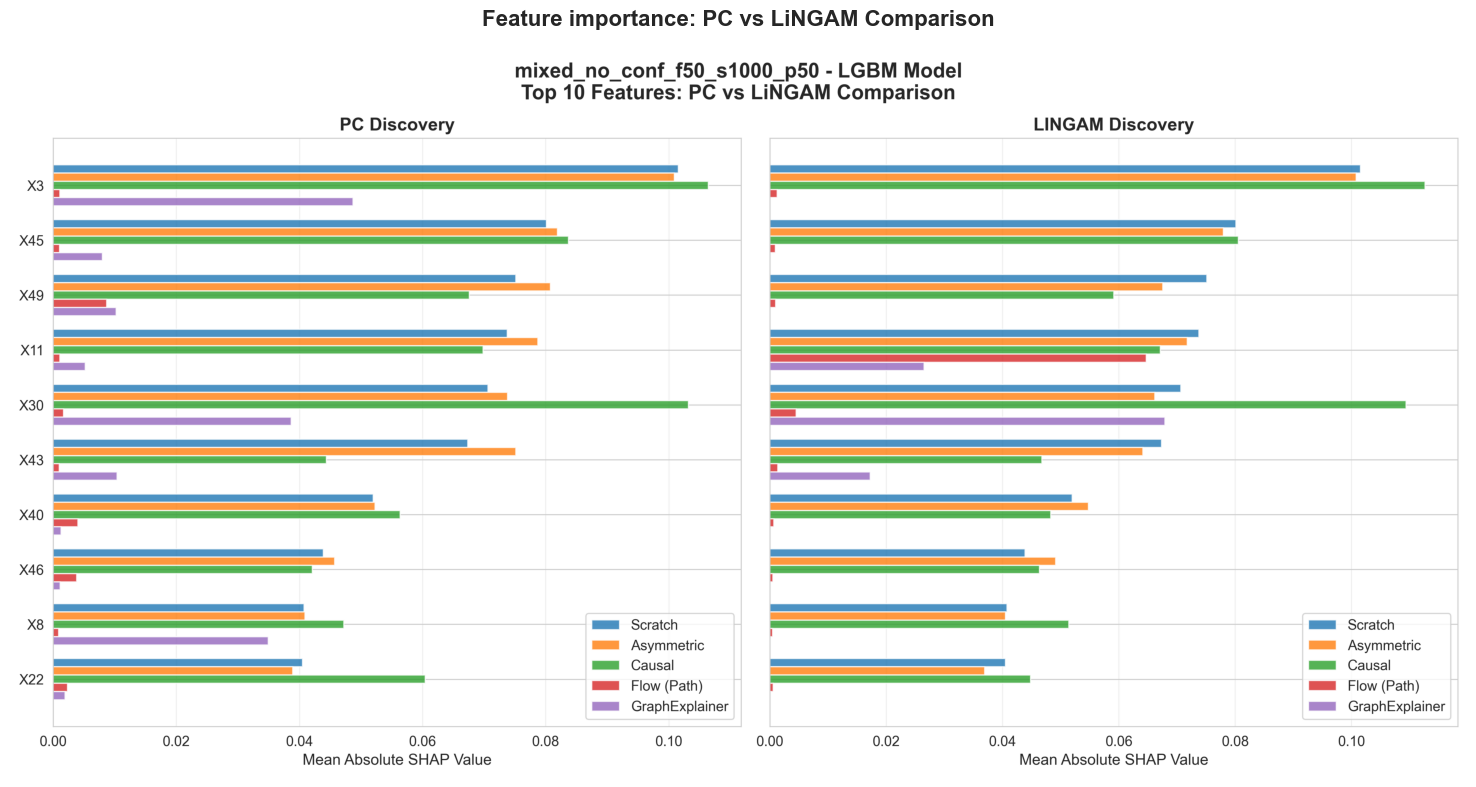

In [10]:
# Display the PC vs LiNGAM comparison created in Step 6
viz_path = base_path / 'pc_vs_lingam_comparison.png'

if viz_path.exists():
    img = Image.open(viz_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Feature importance: PC vs LiNGAM Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️  Visualization not found at {viz_path}")

## 4. Top 10 Features Analysis (Filtered to Causal DAG)

**IMPORTANT**: All analyses below use the **SAME** top 10 features (based on Scratch importance of causal features). This ensures we're comparing how different methods rank the SAME set of features, rather than comparing different feature sets.

The canonical top 10 features are defined in the first cell below and reused throughout all subsequent analyses.

In [11]:
# Define the CANONICAL top 10 features for ALL subsequent analyses
# Based on Scratch importance, filtered to causal graph features
# This ensures ALL charts and analyses compare the SAME features

scratch_importance_filtered = scratch_importance[features_in_causal_graph]

# Get top 10 from filtered features
top_10_filtered_indices = np.argsort(scratch_importance_filtered)[-10:][::-1]
top_10_indices = [features_in_causal_graph[i] for i in top_10_filtered_indices]
top_10_features = [feature_names[i] for i in top_10_indices]

print("="*80)
print("CANONICAL TOP 10 FEATURES (used for ALL subsequent analyses)")
print("="*80)
print("Based on: Scratch importance, filtered to causal graph features")
print("These same 10 features will be used in all comparisons below.")
print()
print("Top 10 Features (by Scratch importance, filtered to causal graph):")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    in_causal = "✓ IN CAUSAL GRAPH" 
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {scratch_importance[idx]:.4f} {is_parent} {in_causal}")

# Count how many are true parents
n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")
print(f"→ All 10/10 features are in the causal graph (by design)")
print("="*80)

CANONICAL TOP 10 FEATURES (used for ALL subsequent analyses)
Based on: Scratch importance, filtered to causal graph features
These same 10 features will be used in all comparisons below.

Top 10 Features (by Scratch importance, filtered to causal graph):
 1. X3    (idx= 3) - Importance: 0.1016 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH
 2. X45   (idx=45) - Importance: 0.0801 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH
 3. X49   (idx=49) - Importance: 0.0752 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH
 4. X11   (idx=11) - Importance: 0.0738 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH
 5. X30   (idx=30) - Importance: 0.0707 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH
 6. X43   (idx=43) - Importance: 0.0674  ✓ IN CAUSAL GRAPH
 7. X40   (idx=40) - Importance: 0.0520 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH
 8. X46   (idx=46) - Importance: 0.0439 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH
 9. X8    (idx= 8) - Importance: 0.0408 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH
10. X22   (idx=22) - Importance: 0.0405 ✓ TRUE PARENT ✓ IN CAUSAL GRAPH

→ 9/10 top features are true Y parent

In [12]:
# Show PC Asymmetric importance for the CANONICAL top 10 features
# (Using the same top 10 features defined by Scratch importance above)

print("PC Asymmetric importance for the CANONICAL Top 10 Features:")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {pc_asym_importance[idx]:.4f} {is_parent}")

# Count how many are true parents

n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

PC Asymmetric importance for the CANONICAL Top 10 Features:
 1. X3    (idx= 3) - Importance: 0.1009 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0819 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0808 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0787 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.0738 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0751 
 7. X40   (idx=40) - Importance: 0.0523 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0457 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0409 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0389 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [13]:
# Show LiNGAM Asymmetric importance for the CANONICAL top 10 features
# (Using the same top 10 features defined by Scratch importance above)

print("LiNGAM Asymmetric importance for the CANONICAL Top 10 Features:")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {lingam_asym_importance[idx]:.4f} {is_parent}")

# Count how many are true parents

n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

LiNGAM Asymmetric importance for the CANONICAL Top 10 Features:
 1. X3    (idx= 3) - Importance: 0.1008 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0780 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0676 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0718 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.0662 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0642 
 7. X40   (idx=40) - Importance: 0.0548 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0491 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0405 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0369 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [14]:
# Show PC Causal importance for the CANONICAL top 10 features
# (Using the same top 10 features defined by Scratch importance above)

print("PC Causal importance for the CANONICAL Top 10 Features:")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {pc_causal_importance[idx]:.4f} {is_parent}")

# Count how many are true parents

n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

PC Causal importance for the CANONICAL Top 10 Features:
 1. X3    (idx= 3) - Importance: 0.1064 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0837 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0676 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0698 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.1032 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0444 
 7. X40   (idx=40) - Importance: 0.0564 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0421 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0472 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0605 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [15]:
# Show LiNGAM Causal importance for the CANONICAL top 10 features
# (Using the same top 10 features defined by Scratch importance above)

print("LiNGAM Causal importance for the CANONICAL Top 10 Features:")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {lingam_causal_importance[idx]:.4f} {is_parent}")

# Count how many are true parents

n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

LiNGAM Causal importance for the CANONICAL Top 10 Features:
 1. X3    (idx= 3) - Importance: 0.1127 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0806 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0592 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0672 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.1094 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0468 
 7. X40   (idx=40) - Importance: 0.0483 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0464 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0514 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0448 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [16]:
# Show PC Flow importance for the CANONICAL top 10 features
# (Using the same top 10 features defined by Scratch importance above)

print("PC Flow importance for the CANONICAL Top 10 Features:")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {pc_flow_importance[idx]:.4f} {is_parent}")

# Count how many are true parents

n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

PC Flow importance for the CANONICAL Top 10 Features:
 1. X3    (idx= 3) - Importance: 0.0011 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0010 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0087 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0011 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.0017 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0010 
 7. X40   (idx=40) - Importance: 0.0040 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0038 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0009 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0023 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [17]:
# Show LiNGAM Flow importance for the CANONICAL top 10 features
# (Using the same top 10 features defined by Scratch importance above)

print("LiNGAM Flow importance for the CANONICAL Top 10 Features:")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {lingam_flow_importance[idx]:.4f} {is_parent}")

# Count how many are true parents

n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

LiNGAM Flow importance for the CANONICAL Top 10 Features:
 1. X3    (idx= 3) - Importance: 0.0012 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0009 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0010 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0647 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.0045 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0014 
 7. X40   (idx=40) - Importance: 0.0007 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0005 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0005 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0006 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [18]:
# Show LiNGAM Flow Real importance for the CANONICAL top 10 features
# (Using the same top 10 features defined by Scratch importance above)

print("LiNGAM Flow Real importance for the CANONICAL Top 10 Features:")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {lingam_flow_real_importance[idx]:.4f} {is_parent}")

# Count how many are true parents

n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

LiNGAM Flow Real importance for the CANONICAL Top 10 Features:
 1. X3    (idx= 3) - Importance: 0.0000 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0000 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0000 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0265 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.0680 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0172 
 7. X40   (idx=40) - Importance: 0.0000 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0000 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0000 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0001 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [19]:
# Show PC Flow Real importance for the CANONICAL top 10 features
# (Using the same top 10 features defined by Scratch importance above)

print("PC Flow Real importance for the CANONICAL Top 10 Features:")
print("="*70)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {pc_flow_real_importance[idx]:.4f} {is_parent}")

# Count how many are true parents

n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

PC Flow Real importance for the CANONICAL Top 10 Features:
 1. X3    (idx= 3) - Importance: 0.0487 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0080 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0102 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0052 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.0387 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0104 
 7. X40   (idx=40) - Importance: 0.0013 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0011 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0349 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0019 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [20]:
# Create detailed comparison table for the CANONICAL top 10 features
# All methods are compared using the SAME set of features

comparison_data = []
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    comparison_data.append({
        'Rank': rank,
        'Feature': fname,
        'Index': idx,
        'True Parent': 'Yes' if idx in true_parents else 'No',
        'Scratch': scratch_importance[idx],
        'PC_Asym': pc_asym_importance[idx],
        'LiNGAM_Asym': lingam_asym_importance[idx],
        'PC_Causal': pc_causal_importance[idx],
        'LiNGAM_Causal': lingam_causal_importance[idx],
        'PC_Flow': pc_flow_importance[idx],
        'LiNGAM_Flow': lingam_flow_importance[idx],
        'PC_Flow_Real': pc_flow_real_importance[idx],
        'LiNGAM_Flow_Real': lingam_flow_real_importance[idx],
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nDetailed comparison for CANONICAL Top 10 features:")
print("="*80)
print(comparison_df.to_string(index=False))


Detailed comparison for CANONICAL Top 10 features:
 Rank Feature  Index True Parent  Scratch  PC_Asym  LiNGAM_Asym  PC_Causal  LiNGAM_Causal  PC_Flow  LiNGAM_Flow  PC_Flow_Real  LiNGAM_Flow_Real
    1      X3      3         Yes 0.101557 0.100923     0.100831   0.106426       0.112655 0.001123     0.001246      0.048706          0.000000
    2     X45     45         Yes 0.080144 0.081911     0.078005   0.083715       0.080576 0.001045     0.000937      0.008012          0.000000
    3     X49     49         Yes 0.075162 0.080786     0.067551   0.067627       0.059157 0.008712     0.000982      0.010244          0.000000
    4     X11     11         Yes 0.073760 0.078727     0.071775   0.069839       0.067166 0.001079     0.064724      0.005205          0.026510
    5     X30     30         Yes 0.070657 0.073838     0.066204   0.103201       0.109417 0.001683     0.004546      0.038654          0.067954
    6     X43     43          No 0.067374 0.075145     0.064152   0.044392       0.0

## 5. Method Correlations

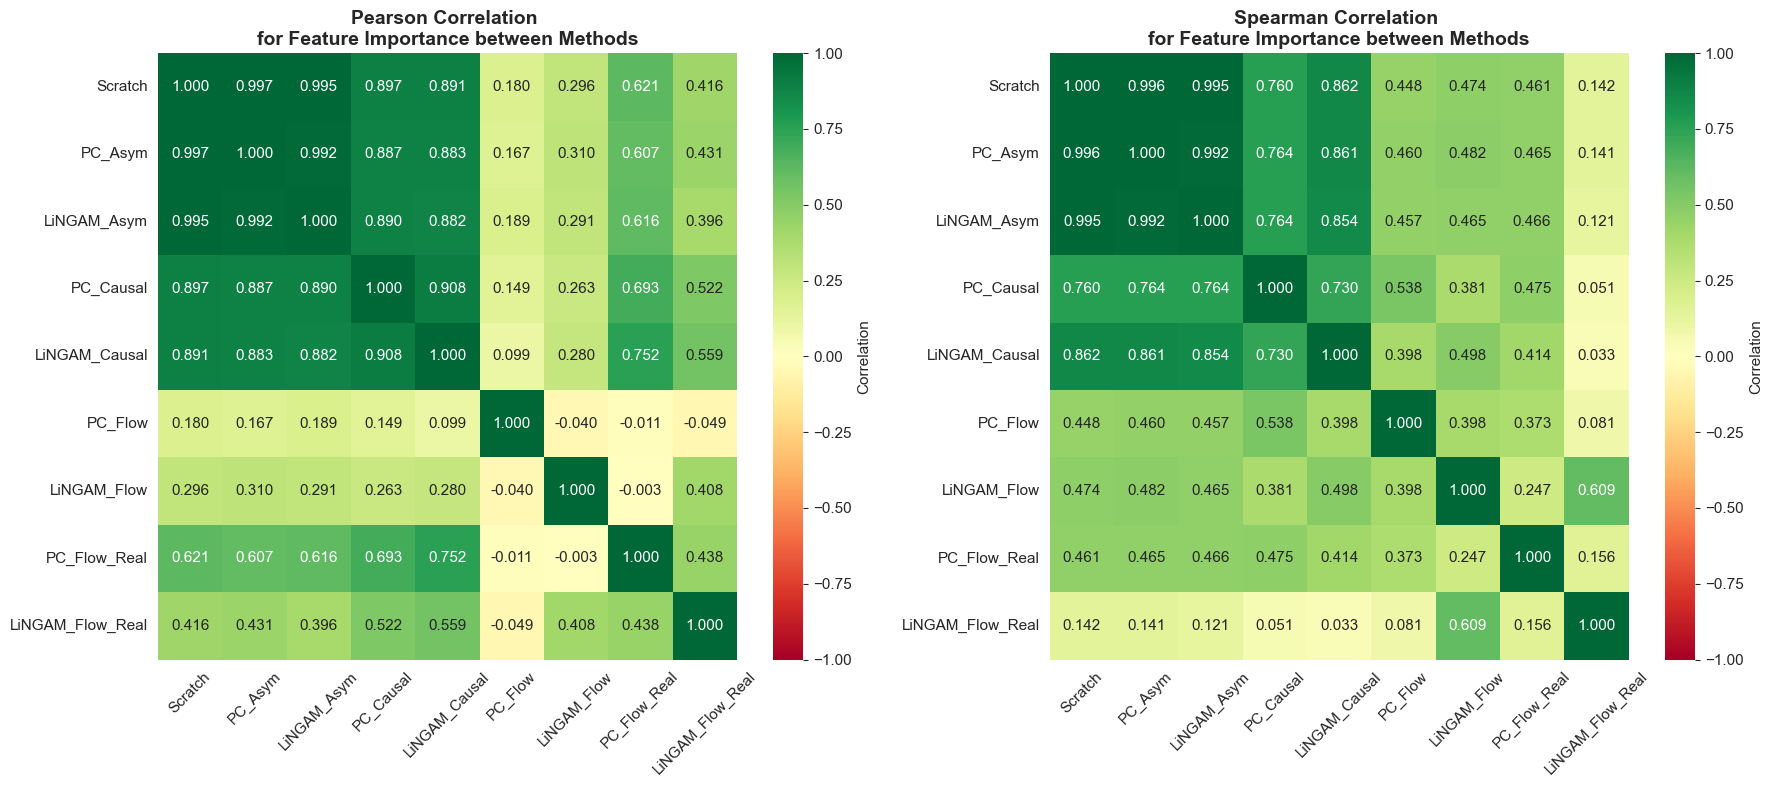


Key observations:
  - Scratch vs PC_Asym: Pearson=0.997, Spearman=0.996
  - Scratch vs LiNGAM_Asym: Pearson=0.995, Spearman=0.995
  - PC_Flow vs LiNGAM_Flow: Pearson=-0.040, Spearman=0.398
  - PC_Flow_Real vs LiNGAM_Flow_Real: Pearson=0.438, Spearman=0.156
  - PC_Flow vs PC_Flow_Real: Pearson=-0.011, Spearman=0.373
  - LiNGAM_Flow vs LiNGAM_Flow_Real: Pearson=0.408, Spearman=0.609


In [21]:
# Calculate correlations between all methods
methods = {
    'Scratch': scratch_importance,
    'PC_Asym': pc_asym_importance,
    'LiNGAM_Asym': lingam_asym_importance,
    'PC_Causal': pc_causal_importance,
    'LiNGAM_Causal': lingam_causal_importance,
    'PC_Flow': pc_flow_importance,
    'LiNGAM_Flow': lingam_flow_importance,
    'PC_Flow_Real': pc_flow_real_importance,
    'LiNGAM_Flow_Real': lingam_flow_real_importance,
}

# Compute correlation matrix
method_names = list(methods.keys())
n_methods = len(method_names)
corr_matrix_pearson = np.zeros((n_methods, n_methods))
corr_matrix_spearman = np.zeros((n_methods, n_methods))

for i, method1 in enumerate(method_names):
    for j, method2 in enumerate(method_names):
        pearson_corr, _ = pearsonr(methods[method1], methods[method2])
        spearman_corr, _ = spearmanr(methods[method1], methods[method2])
        corr_matrix_pearson[i, j] = pearson_corr
        corr_matrix_spearman[i, j] = spearman_corr

# Plot correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pearson correlation
sns.heatmap(corr_matrix_pearson, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            xticklabels=method_names, yticklabels=method_names, 
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Pearson Correlation \nfor Feature Importance between Methods', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Spearman correlation
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            xticklabels=method_names, yticklabels=method_names,
            vmin=-1, vmax=1, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Spearman Correlation \nfor Feature Importance between Methods', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  - Scratch vs PC_Asym: Pearson={corr_matrix_pearson[0, 1]:.3f}, Spearman={corr_matrix_spearman[0, 1]:.3f}")
print(f"  - Scratch vs LiNGAM_Asym: Pearson={corr_matrix_pearson[0, 2]:.3f}, Spearman={corr_matrix_spearman[0, 2]:.3f}")
print(f"  - PC_Flow vs LiNGAM_Flow: Pearson={corr_matrix_pearson[5, 6]:.3f}, Spearman={corr_matrix_spearman[5, 6]:.3f}")
print(f"  - PC_Flow_Real vs LiNGAM_Flow_Real: Pearson={corr_matrix_pearson[7, 8]:.3f}, Spearman={corr_matrix_spearman[7, 8]:.3f}")
print(f"  - PC_Flow vs PC_Flow_Real: Pearson={corr_matrix_pearson[5, 7]:.3f}, Spearman={corr_matrix_spearman[5, 7]:.3f}")
print(f"  - LiNGAM_Flow vs LiNGAM_Flow_Real: Pearson={corr_matrix_pearson[6, 8]:.3f}, Spearman={corr_matrix_spearman[6, 8]:.3f}")

### 5.1 Instance-Level SHAP Value Correlations

While the previous analysis looked at correlations between aggregated feature importance values, this analysis examines correlations between the raw SHAP values themselves at the instance-feature level. This reveals how well methods agree on individual predictions.

Flattened SHAP value shapes:
  Scratch: (5000,)
  PC_Asym: (5000,)
  LiNGAM_Asym: (5000,)
  PC_Causal: (5000,)
  LiNGAM_Causal: (5000,)
  PC_Flow: (5000,)
  LiNGAM_Flow: (5000,)
  PC_Flow_Real: (5000,)
  LiNGAM_Flow_Real: (5000,)


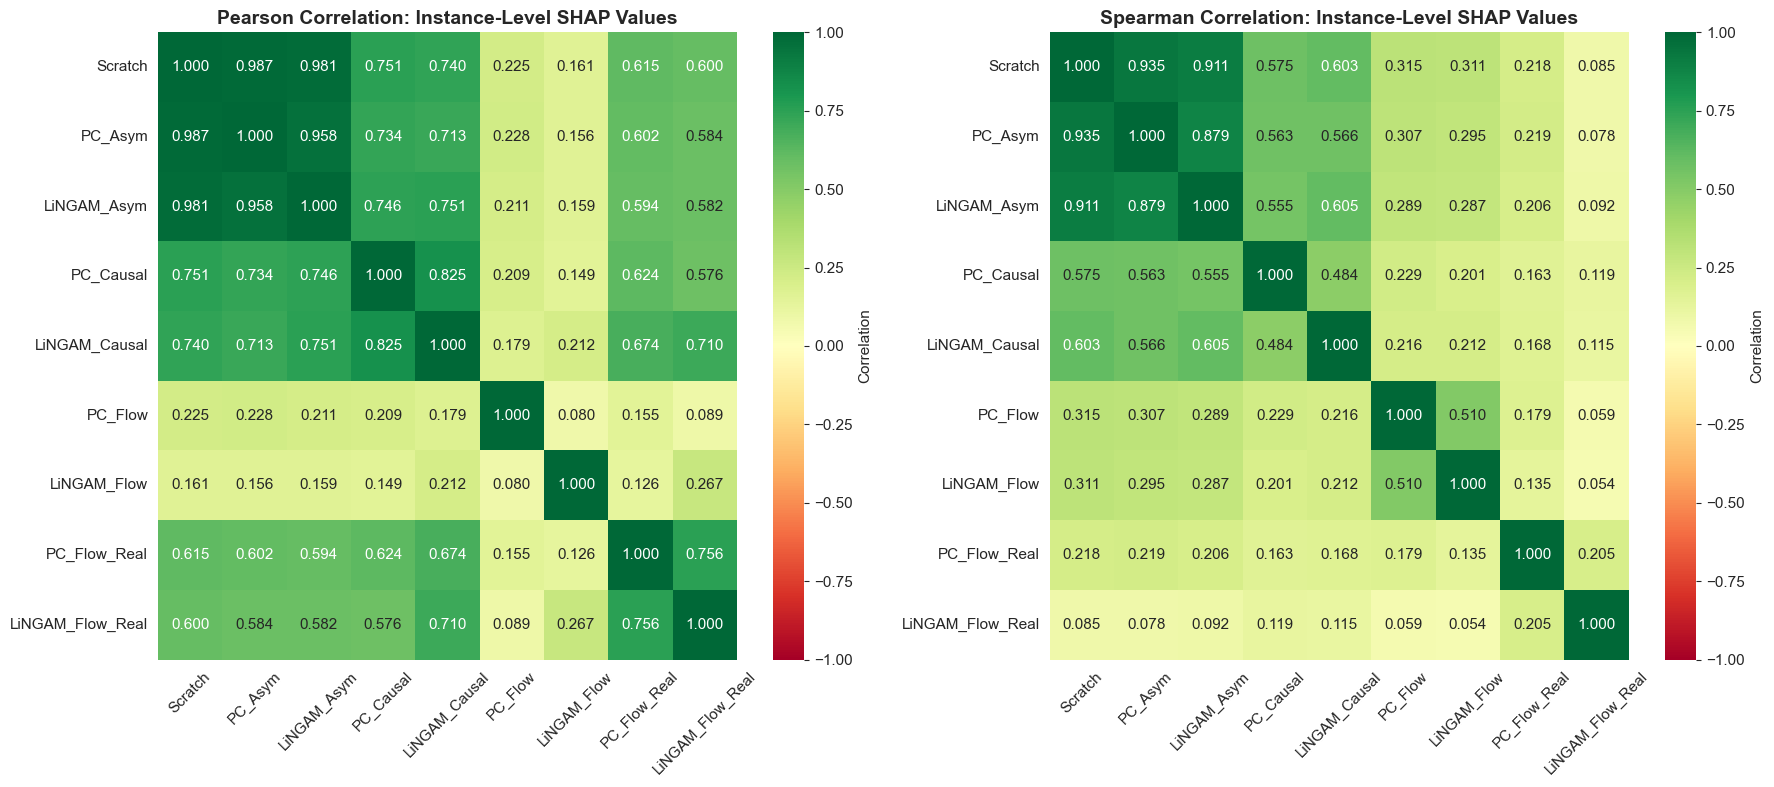


Instance-Level SHAP Value Correlations:
Key observations:
  - Scratch vs PC_Asym: Pearson=0.987, Spearman=0.935
  - Scratch vs LiNGAM_Asym: Pearson=0.981, Spearman=0.911
  - PC_Asym vs LiNGAM_Asym: Pearson=0.958, Spearman=0.879
  - PC_Flow vs LiNGAM_Flow: Pearson=0.080, Spearman=0.510
  - PC_Flow_Real vs LiNGAM_Flow_Real: Pearson=0.756, Spearman=0.205
  - PC_Flow vs PC_Flow_Real: Pearson=0.155, Spearman=0.179
  - LiNGAM_Flow vs LiNGAM_Flow_Real: Pearson=0.267, Spearman=0.054

Comparison with Feature Importance Correlations:
Note: These correlations are typically lower than feature importance correlations
because they capture agreement at the instance-feature level, which is more
granular than aggregated importance values.


In [22]:
# Calculate correlations between raw SHAP values (instance-level)
# Flatten SHAP value matrices to compare entire distributions

shap_methods = {
    'Scratch': scratch_values,
    'PC_Asym': pc_asym_values,
    'LiNGAM_Asym': lingam_asym_values,
    'PC_Causal': pc_causal_values,
    'LiNGAM_Causal': lingam_causal_values,
    'PC_Flow': pc_flow_values,
    'LiNGAM_Flow': lingam_flow_values,
    'PC_Flow_Real': pc_flow_real_values,
    'LiNGAM_Flow_Real': lingam_flow_real_values,
}

# Flatten each SHAP value matrix (instances × features) to 1D array
flattened_shap = {}
for method, shap_vals in shap_methods.items():
    flattened_shap[method] = shap_vals.flatten()

print("Flattened SHAP value shapes:")
for method, flat_vals in flattened_shap.items():
    print(f"  {method}: {flat_vals.shape}")

# Compute correlation matrices for raw SHAP values
shap_method_names = list(flattened_shap.keys())
n_shap_methods = len(shap_method_names)
shap_corr_pearson = np.zeros((n_shap_methods, n_shap_methods))
shap_corr_spearman = np.zeros((n_shap_methods, n_shap_methods))

for i, method1 in enumerate(shap_method_names):
    for j, method2 in enumerate(shap_method_names):
        pearson_corr, _ = pearsonr(flattened_shap[method1], flattened_shap[method2])
        spearman_corr, _ = spearmanr(flattened_shap[method1], flattened_shap[method2])
        shap_corr_pearson[i, j] = pearson_corr
        shap_corr_spearman[i, j] = spearman_corr

# Plot correlation heatmaps for raw SHAP values
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pearson correlation
sns.heatmap(shap_corr_pearson, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            xticklabels=shap_method_names, yticklabels=shap_method_names, 
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Pearson Correlation: Instance-Level SHAP Values', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Spearman correlation
sns.heatmap(shap_corr_spearman, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            xticklabels=shap_method_names, yticklabels=shap_method_names,
            vmin=-1, vmax=1, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Spearman Correlation: Instance-Level SHAP Values', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print("\nInstance-Level SHAP Value Correlations:")
print("="*80)
print("Key observations:")
print(f"  - Scratch vs PC_Asym: Pearson={shap_corr_pearson[0, 1]:.3f}, Spearman={shap_corr_spearman[0, 1]:.3f}")
print(f"  - Scratch vs LiNGAM_Asym: Pearson={shap_corr_pearson[0, 2]:.3f}, Spearman={shap_corr_spearman[0, 2]:.3f}")
print(f"  - PC_Asym vs LiNGAM_Asym: Pearson={shap_corr_pearson[1, 2]:.3f}, Spearman={shap_corr_spearman[1, 2]:.3f}")
print(f"  - PC_Flow vs LiNGAM_Flow: Pearson={shap_corr_pearson[5, 6]:.3f}, Spearman={shap_corr_spearman[5, 6]:.3f}")
print(f"  - PC_Flow_Real vs LiNGAM_Flow_Real: Pearson={shap_corr_pearson[7, 8]:.3f}, Spearman={shap_corr_spearman[7, 8]:.3f}")
print(f"  - PC_Flow vs PC_Flow_Real: Pearson={shap_corr_pearson[5, 7]:.3f}, Spearman={shap_corr_spearman[5, 7]:.3f}")
print(f"  - LiNGAM_Flow vs LiNGAM_Flow_Real: Pearson={shap_corr_pearson[6, 8]:.3f}, Spearman={shap_corr_spearman[6, 8]:.3f}")

print("\nComparison with Feature Importance Correlations:")
print("Note: These correlations are typically lower than feature importance correlations")
print("because they capture agreement at the instance-feature level, which is more")
print("granular than aggregated importance values.")

## 6. PC vs LiNGAM Detailed Comparison

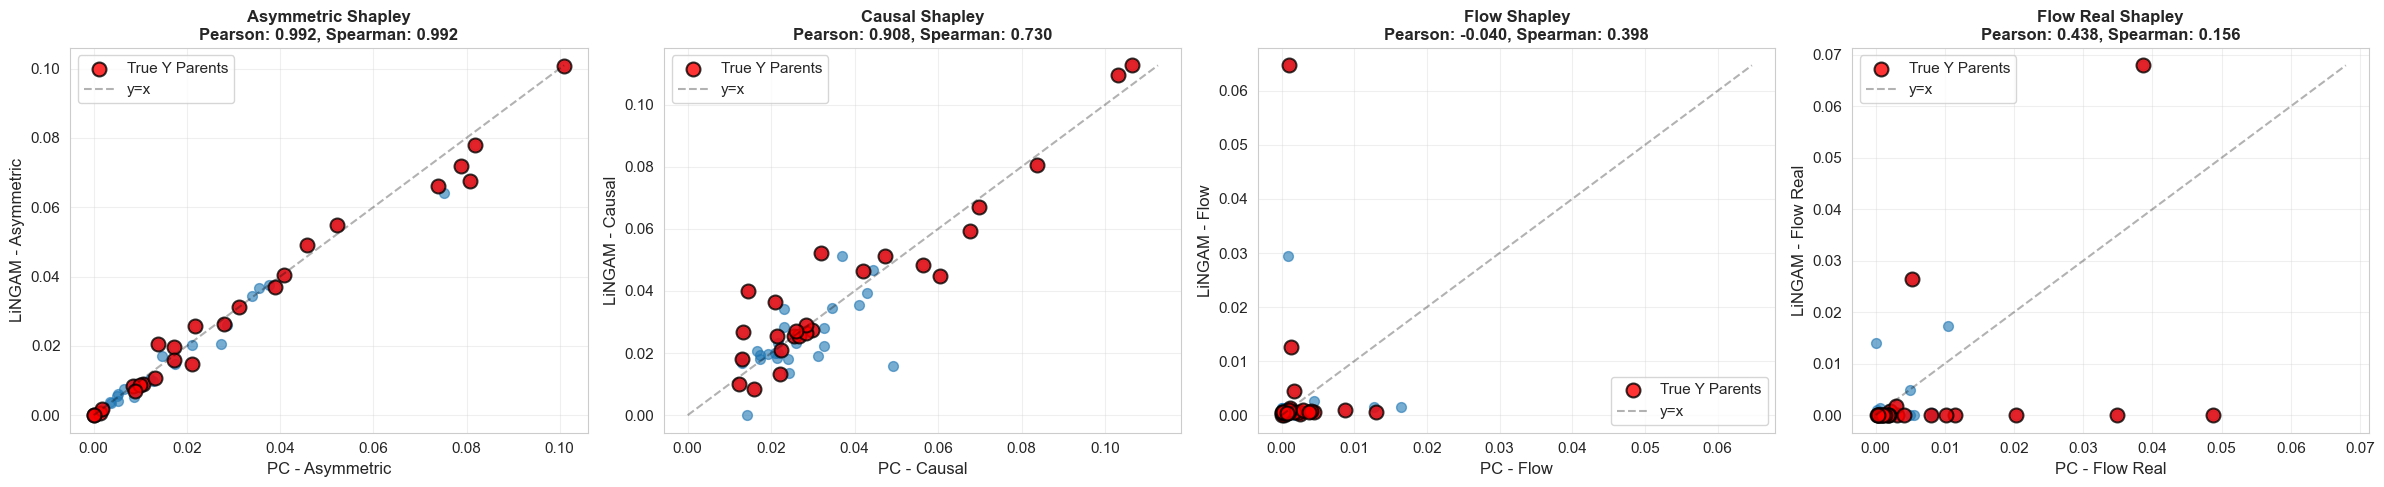

In [23]:
# Compare PC vs LiNGAM for each causal method
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

comparisons = [
    ('Asymmetric', pc_asym_importance[features_in_causal_graph], lingam_asym_importance[features_in_causal_graph]),
    ('Causal', pc_causal_importance[features_in_causal_graph], lingam_causal_importance[features_in_causal_graph]),
    ('Flow', pc_flow_importance[features_in_causal_graph], lingam_flow_importance[features_in_causal_graph]),
    ('Flow Real', pc_flow_real_importance[features_in_causal_graph], lingam_flow_real_importance[features_in_causal_graph])
]

for ax, (method_name, pc_imp, lingam_imp) in zip(axes, comparisons):
    # Scatter plot
    ax.scatter(pc_imp, lingam_imp, alpha=0.6, s=50)
    
    # Highlight true parents
    true_parent_mask = [i in true_parents for i in range(len(pc_imp))]
    ax.scatter(pc_imp[true_parent_mask], lingam_imp[true_parent_mask], 
               alpha=0.8, s=100, c='red', label='True Y Parents', edgecolors='black', linewidths=1.5)
    
    # Add diagonal line
    max_val = max(pc_imp.max(), lingam_imp.max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='y=x')
    
    # Calculate correlation
    pearson_corr, _ = pearsonr(pc_imp, lingam_imp)
    spearman_corr, _ = spearmanr(pc_imp, lingam_imp)
    
    ax.set_xlabel(f'PC - {method_name}', fontsize=12)
    ax.set_ylabel(f'LiNGAM - {method_name}', fontsize=12)
    ax.set_title(f'{method_name} Shapley\nPearson: {pearson_corr:.3f}, Spearman: {spearman_corr:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Distribution Comparison

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/3144320076.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_parent_importance, parent_importance],
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/3144320076.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_parent_importance, parent_importance],
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/3144320076.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_parent_importance, parent_importance],
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel

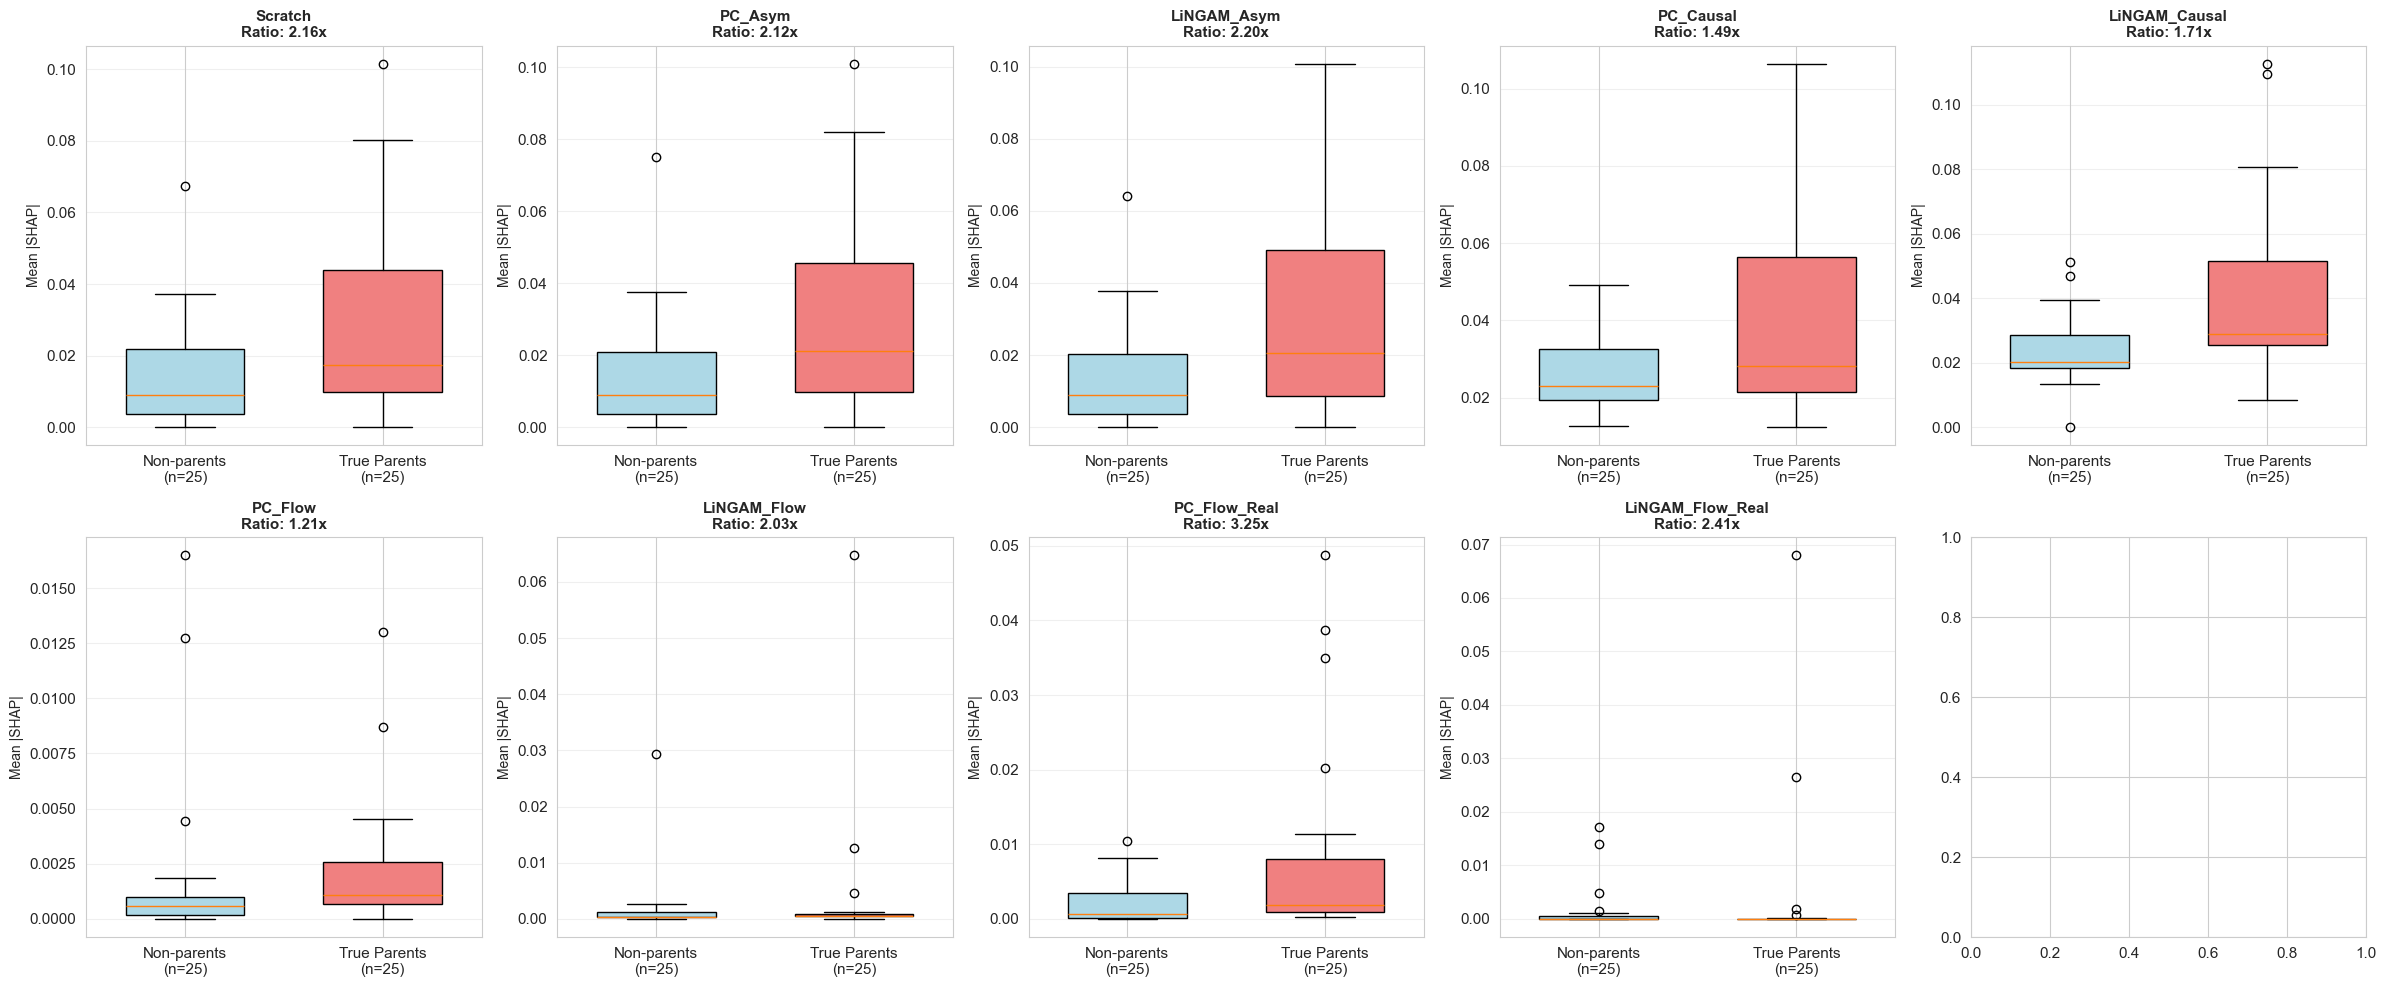

Ratio = Mean SHAP (True Parents) / Mean SHAP (Non-Parents)
Higher ratio = Better separation between parents and non-parents


In [24]:
# Compare distributions of SHAP values for true parents vs non-parents
fig, axes = plt.subplots(2, 5, figsize=(24, 10))

all_methods = [
    ('Scratch', scratch_importance),
    ('PC_Asym', pc_asym_importance),
    ('LiNGAM_Asym', lingam_asym_importance),
    ('PC_Causal', pc_causal_importance),
    ('LiNGAM_Causal', lingam_causal_importance),
    ('PC_Flow', pc_flow_importance),
    ('LiNGAM_Flow', lingam_flow_importance),
    ('PC_Flow_Real', pc_flow_real_importance),
    ('LiNGAM_Flow_Real', lingam_flow_real_importance),
]

for idx, (method_name, importance) in enumerate(all_methods):
    ax = axes[idx // 5, idx % 5]
    
    # Separate true parents and non-parents
    parent_importance = importance[list(true_parents)]
    non_parent_importance = importance[[i for i in range(len(importance)) if i not in true_parents]]
    
    # Box plot
    bp = ax.boxplot([non_parent_importance, parent_importance], 
                     labels=['Non-parents\n(n=25)', 'True Parents\n(n=25)'],
                     patch_artist=True, widths=0.6)
    
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    # Calculate means
    mean_non_parent = non_parent_importance.mean()
    mean_parent = parent_importance.mean()
    ratio = mean_parent / mean_non_parent if mean_non_parent > 0 else float('inf')
    
    ax.set_title(f'{method_name}\nRatio: {ratio:.2f}x', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean |SHAP|', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Ratio = Mean SHAP (True Parents) / Mean SHAP (Non-Parents)")
print("Higher ratio = Better separation between parents and non-parents")

## 8. Top-K Agreement Analysis

In [25]:
# Check agreement in top-K features across methods
k_values = [5, 10, 15, 20, 25]

agreement_data = []

for k in k_values:
    # Get top-k for each method
    top_k_scratch = set(np.argsort(scratch_importance)[-k:])
    top_k_pc_asym = set(np.argsort(pc_asym_importance)[-k:])
    top_k_pc_causal = set(np.argsort(pc_causal_importance)[-k:])
    top_k_pc_flow = set(np.argsort(pc_flow_importance)[-k:])
    top_k_pc_flow_real = set(np.argsort(pc_flow_real_importance)[-k:])
    top_k_lingam_asym = set(np.argsort(lingam_asym_importance)[-k:])
    top_k_lingam_causal = set(np.argsort(lingam_causal_importance)[-k:])
    top_k_lingam_flow = set(np.argsort(lingam_flow_importance)[-k:])
    top_k_lingam_flow_real = set(np.argsort(lingam_flow_real_importance)[-k:])
    
    # Calculate overlaps
    agreement_data.append({
        'K': k,
        'Scratch ∩ PC_Asym': len(top_k_scratch & top_k_pc_asym),
        'Scratch ∩ LiNGAM_Asym': len(top_k_scratch & top_k_lingam_asym),
        'PC_Asym ∩ LiNGAM_Asym': len(top_k_pc_asym & top_k_lingam_asym),
        'PC_Flow ∩ LiNGAM_Flow': len(top_k_pc_flow & top_k_lingam_flow),
        'PC_Flow ∩ PC_Flow_Real': len(top_k_pc_flow & top_k_pc_flow_real),
        'LiNGAM_Flow ∩ LiNGAM_Flow_Real': len(top_k_lingam_flow & top_k_lingam_flow_real),
        'PC_Flow_Real ∩ LiNGAM_Flow_Real': len(top_k_pc_flow_real & top_k_lingam_flow_real),
        'All PC methods': len(top_k_pc_asym & top_k_pc_causal & top_k_pc_flow & top_k_pc_flow_real),
        'All LiNGAM methods': len(top_k_lingam_asym & top_k_lingam_causal & top_k_lingam_flow & top_k_lingam_flow_real),
        'True parents in Scratch': len(top_k_scratch & true_parents),
        'True parents in PC_Flow': len(top_k_pc_flow & true_parents),
        'True parents in LiNGAM_Flow': len(top_k_lingam_flow & true_parents),
        'True parents in PC_Flow_Real': len(top_k_pc_flow_real & true_parents),
        'True parents in LiNGAM_Flow_Real': len(top_k_lingam_flow_real & true_parents),
    })

agreement_df = pd.DataFrame(agreement_data)
print("Top-K Agreement Analysis:")
print("="*80)
print(agreement_df.to_string(index=False))

Top-K Agreement Analysis:
 K  Scratch ∩ PC_Asym  Scratch ∩ LiNGAM_Asym  PC_Asym ∩ LiNGAM_Asym  PC_Flow ∩ LiNGAM_Flow  PC_Flow ∩ PC_Flow_Real  LiNGAM_Flow ∩ LiNGAM_Flow_Real  PC_Flow_Real ∩ LiNGAM_Flow_Real  All PC methods  All LiNGAM methods  True parents in Scratch  True parents in PC_Flow  True parents in LiNGAM_Flow  True parents in PC_Flow_Real  True parents in LiNGAM_Flow_Real
 5                  4                      5                      4                      0                       0                               3                                1               0                   2                        5                        3                            3                             5                                 2
10                 10                      9                      9                      3                       2                               6                                2               1                   3                        9                

## 9. Feature Ranking Comparison

In [26]:
# Create ranking comparison for top 20 features
top_20_indices = np.argsort(scratch_importance)[-20:][::-1]

ranking_data = []
for idx in top_20_indices:
    fname = feature_names[idx]
    
    # Get ranks (1 = highest importance)
    rank_scratch = len(scratch_importance) - np.where(np.argsort(scratch_importance)[::-1] == idx)[0][0]
    rank_pc_flow = len(pc_flow_importance) - np.where(np.argsort(pc_flow_importance)[::-1] == idx)[0][0]
    rank_lingam_flow = len(lingam_flow_importance) - np.where(np.argsort(lingam_flow_importance)[::-1] == idx)[0][0]
    rank_pc_flow_real = len(pc_flow_real_importance) - np.where(np.argsort(pc_flow_real_importance)[::-1] == idx)[0][0]
    rank_lingam_flow_real = len(lingam_flow_real_importance) - np.where(np.argsort(lingam_flow_real_importance)[::-1] == idx)[0][0]
    
    ranking_data.append({
        'Feature': fname,
        'Index': idx,
        'True Parent': '✓' if idx in true_parents else '',
        'Scratch_Rank': rank_scratch,
        'PC_Flow_Rank': rank_pc_flow,
        'LiNGAM_Flow_Rank': rank_lingam_flow,
        'PC_Flow_Real_Rank': rank_pc_flow_real,
        'LiNGAM_Flow_Real_Rank': rank_lingam_flow_real,
        'Rank_Diff_PC': abs(rank_scratch - rank_pc_flow),
        'Rank_Diff_LiNGAM': abs(rank_scratch - rank_lingam_flow),
        'Rank_Diff_PC_Real': abs(rank_scratch - rank_pc_flow_real),
        'Rank_Diff_LiNGAM_Real': abs(rank_scratch - rank_lingam_flow_real),
    })

ranking_df = pd.DataFrame(ranking_data)
print("\nTop 20 Features - Ranking Comparison:")
print("="*80)
print(ranking_df.to_string(index=False))


Top 20 Features - Ranking Comparison:
Feature  Index True Parent  Scratch_Rank  PC_Flow_Rank  LiNGAM_Flow_Rank  PC_Flow_Real_Rank  LiNGAM_Flow_Real_Rank  Rank_Diff_PC  Rank_Diff_LiNGAM  Rank_Diff_PC_Real  Rank_Diff_LiNGAM_Real
     X3      3           ✓            50            33                39                 50                     25            17                11                  0                     25
    X45     45           ✓            49            31                35                 41                     14            18                14                  8                     35
    X49     49           ✓            48            47                36                 44                     19             1                12                  4                     29
    X11     11           ✓            47            32                50                 39                     49            15                 3                  8                      2
    X30     30  

## 10. Summary Statistics

In [27]:
# Summary of key findings
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n1. DATASET:")
print(f"   - Name: {DATASET}")
print(f"   - Features: {metadata['n_features']}")
print(f"   - True Y parents: {len(true_parents)}")

print("\n2. TOP-10 FEATURES (by Scratch):")
print(f"   - True parents captured: {n_true_parents_in_top10}/10")
print(f"   - Features: {', '.join(top_10_features)}")

print("\n3. METHOD AGREEMENT (Top-10 overlap):")
k = 10
top_10_scratch = set(np.argsort(scratch_importance)[-k:])
top_10_pc_flow = set(np.argsort(pc_flow_importance)[-k:])
top_10_lingam_flow = set(np.argsort(lingam_flow_importance)[-k:])
top_10_pc_flow_real = set(np.argsort(pc_flow_real_importance)[-k:])
top_10_lingam_flow_real = set(np.argsort(lingam_flow_real_importance)[-k:])

print(f"   - Scratch ∩ PC_Flow: {len(top_10_scratch & top_10_pc_flow)}/10")
print(f"   - Scratch ∩ LiNGAM_Flow: {len(top_10_scratch & top_10_lingam_flow)}/10")
print(f"   - PC_Flow ∩ LiNGAM_Flow: {len(top_10_pc_flow & top_10_lingam_flow)}/10")
print(f"   - Scratch ∩ PC_Flow_Real: {len(top_10_scratch & top_10_pc_flow_real)}/10")
print(f"   - Scratch ∩ LiNGAM_Flow_Real: {len(top_10_scratch & top_10_lingam_flow_real)}/10")
print(f"   - PC_Flow_Real ∩ LiNGAM_Flow_Real: {len(top_10_pc_flow_real & top_10_lingam_flow_real)}/10")

print("\n4. CORRELATION WITH SCRATCH:")
all_methods_summary = [
    ('PC_Flow', pc_flow_importance),
    ('LiNGAM_Flow', lingam_flow_importance),
    ('PC_Flow_Real', pc_flow_real_importance),
    ('LiNGAM_Flow_Real', lingam_flow_real_importance)
]
for method_name, importance in all_methods_summary:
    pearson, _ = pearsonr(scratch_importance, importance)
    spearman, _ = spearmanr(scratch_importance, importance)
    print(f"   - {method_name}: Pearson={pearson:.3f}, Spearman={spearman:.3f}")

print("\n5. TRUE PARENT DETECTION (Mean SHAP ratio):")
for method_name, importance in all_methods:
    parent_imp = importance[list(true_parents)]
    non_parent_imp = importance[[i for i in range(len(importance)) if i not in true_parents]]
    ratio = parent_imp.mean() / non_parent_imp.mean() if non_parent_imp.mean() > 0 else float('inf')
    print(f"   - {method_name}: {ratio:.2f}x")

print("\n" + "="*80)

SUMMARY STATISTICS

1. DATASET:
   - Name: mixed_no_conf_f50_s1000_p50
   - Features: 50
   - True Y parents: 25

2. TOP-10 FEATURES (by Scratch):
   - True parents captured: 9/10
   - Features: X3, X45, X49, X11, X30, X43, X40, X46, X8, X22

3. METHOD AGREEMENT (Top-10 overlap):
   - Scratch ∩ PC_Flow: 3/10
   - Scratch ∩ LiNGAM_Flow: 3/10
   - PC_Flow ∩ LiNGAM_Flow: 3/10
   - Scratch ∩ PC_Flow_Real: 6/10
   - Scratch ∩ LiNGAM_Flow_Real: 3/10
   - PC_Flow_Real ∩ LiNGAM_Flow_Real: 2/10

4. CORRELATION WITH SCRATCH:
   - PC_Flow: Pearson=0.180, Spearman=0.448
   - LiNGAM_Flow: Pearson=0.296, Spearman=0.474
   - PC_Flow_Real: Pearson=0.621, Spearman=0.461
   - LiNGAM_Flow_Real: Pearson=0.416, Spearman=0.142

5. TRUE PARENT DETECTION (Mean SHAP ratio):
   - Scratch: 2.16x
   - PC_Asym: 2.12x
   - LiNGAM_Asym: 2.20x
   - PC_Causal: 1.49x
   - LiNGAM_Causal: 1.71x
   - PC_Flow: 1.21x
   - LiNGAM_Flow: 2.03x
   - PC_Flow_Real: 3.25x
   - LiNGAM_Flow_Real: 2.41x



## 12. Aggregated Comparison: All Methods Side-by-Side

A comprehensive view showing all methods for all top 10 **causal features** in one plot.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/624635691.py:51: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


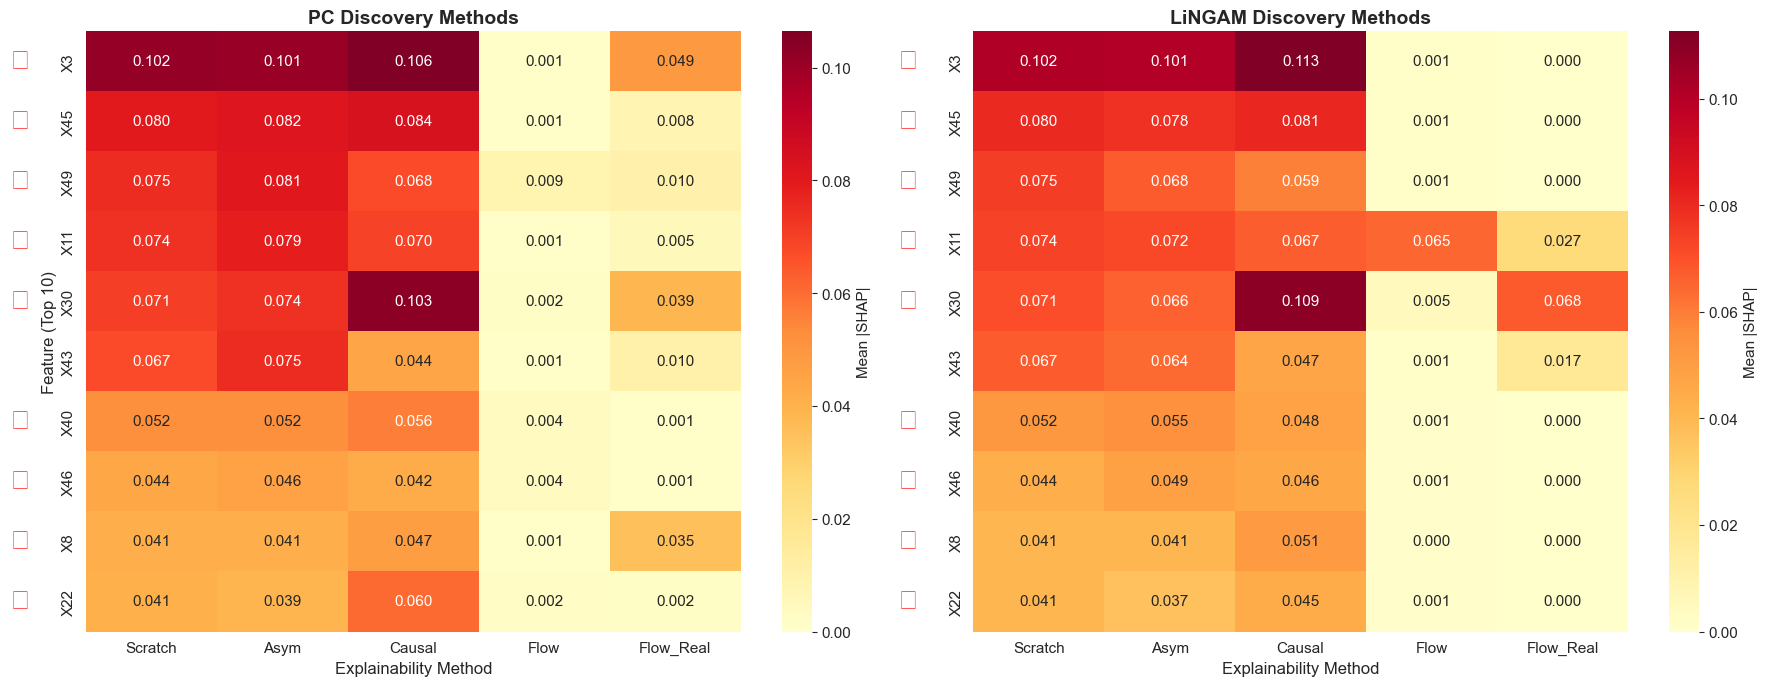

★ = True Y parent

This heatmap shows the mean absolute SHAP value for each feature-method combination.


In [28]:
# Create a comprehensive heatmap showing mean absolute SHAP for top 10 features
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Prepare data for heatmap
methods_list = ['Scratch', 'Asym', 'Causal', 'Flow', 'Flow_Real']
pc_data = []
lingam_data = []

for idx in top_10_indices:
    pc_row = [
        scratch_importance[idx],
        pc_asym_importance[idx],
        pc_causal_importance[idx],
        pc_flow_importance[idx],
        pc_flow_real_importance[idx]
    ]
    lingam_row = [
        scratch_importance[idx],
        lingam_asym_importance[idx],
        lingam_causal_importance[idx],
        lingam_flow_importance[idx],
        lingam_flow_real_importance[idx]
    ]
    pc_data.append(pc_row)
    lingam_data.append(lingam_row)

pc_df = pd.DataFrame(pc_data, columns=methods_list, index=top_10_features)
lingam_df = pd.DataFrame(lingam_data, columns=methods_list, index=top_10_features)

# Plot heatmaps
sns.heatmap(pc_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0], 
            cbar_kws={'label': 'Mean |SHAP|'}, vmin=0)
axes[0].set_title('PC Discovery Methods', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Explainability Method', fontsize=12)
axes[0].set_ylabel('Feature (Top 10)', fontsize=12)

sns.heatmap(lingam_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Mean |SHAP|'}, vmin=0)
axes[1].set_title('LiNGAM Discovery Methods', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Explainability Method', fontsize=12)
axes[1].set_ylabel('')

# Mark true parents
for i, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    if idx in true_parents:
        # Add a star marker for true parents
        for ax in axes:
            ax.text(-0.5, i + 0.5, '★', fontsize=20, color='red', 
                   ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("\nThis heatmap shows the mean absolute SHAP value for each feature-method combination.")

## 13. Instance-Level Comparison

Examine how SHAP values differ across specific test instances for different Shapley methods, focusing on the top 10 **causal features**.

### 13.3 ShapleyFlow: Instance-Level Comparison

Examining how ShapleyFlow values differ across specific test instances for Scratch, PC, and LiNGAM methods.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/2525277425.py:70: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


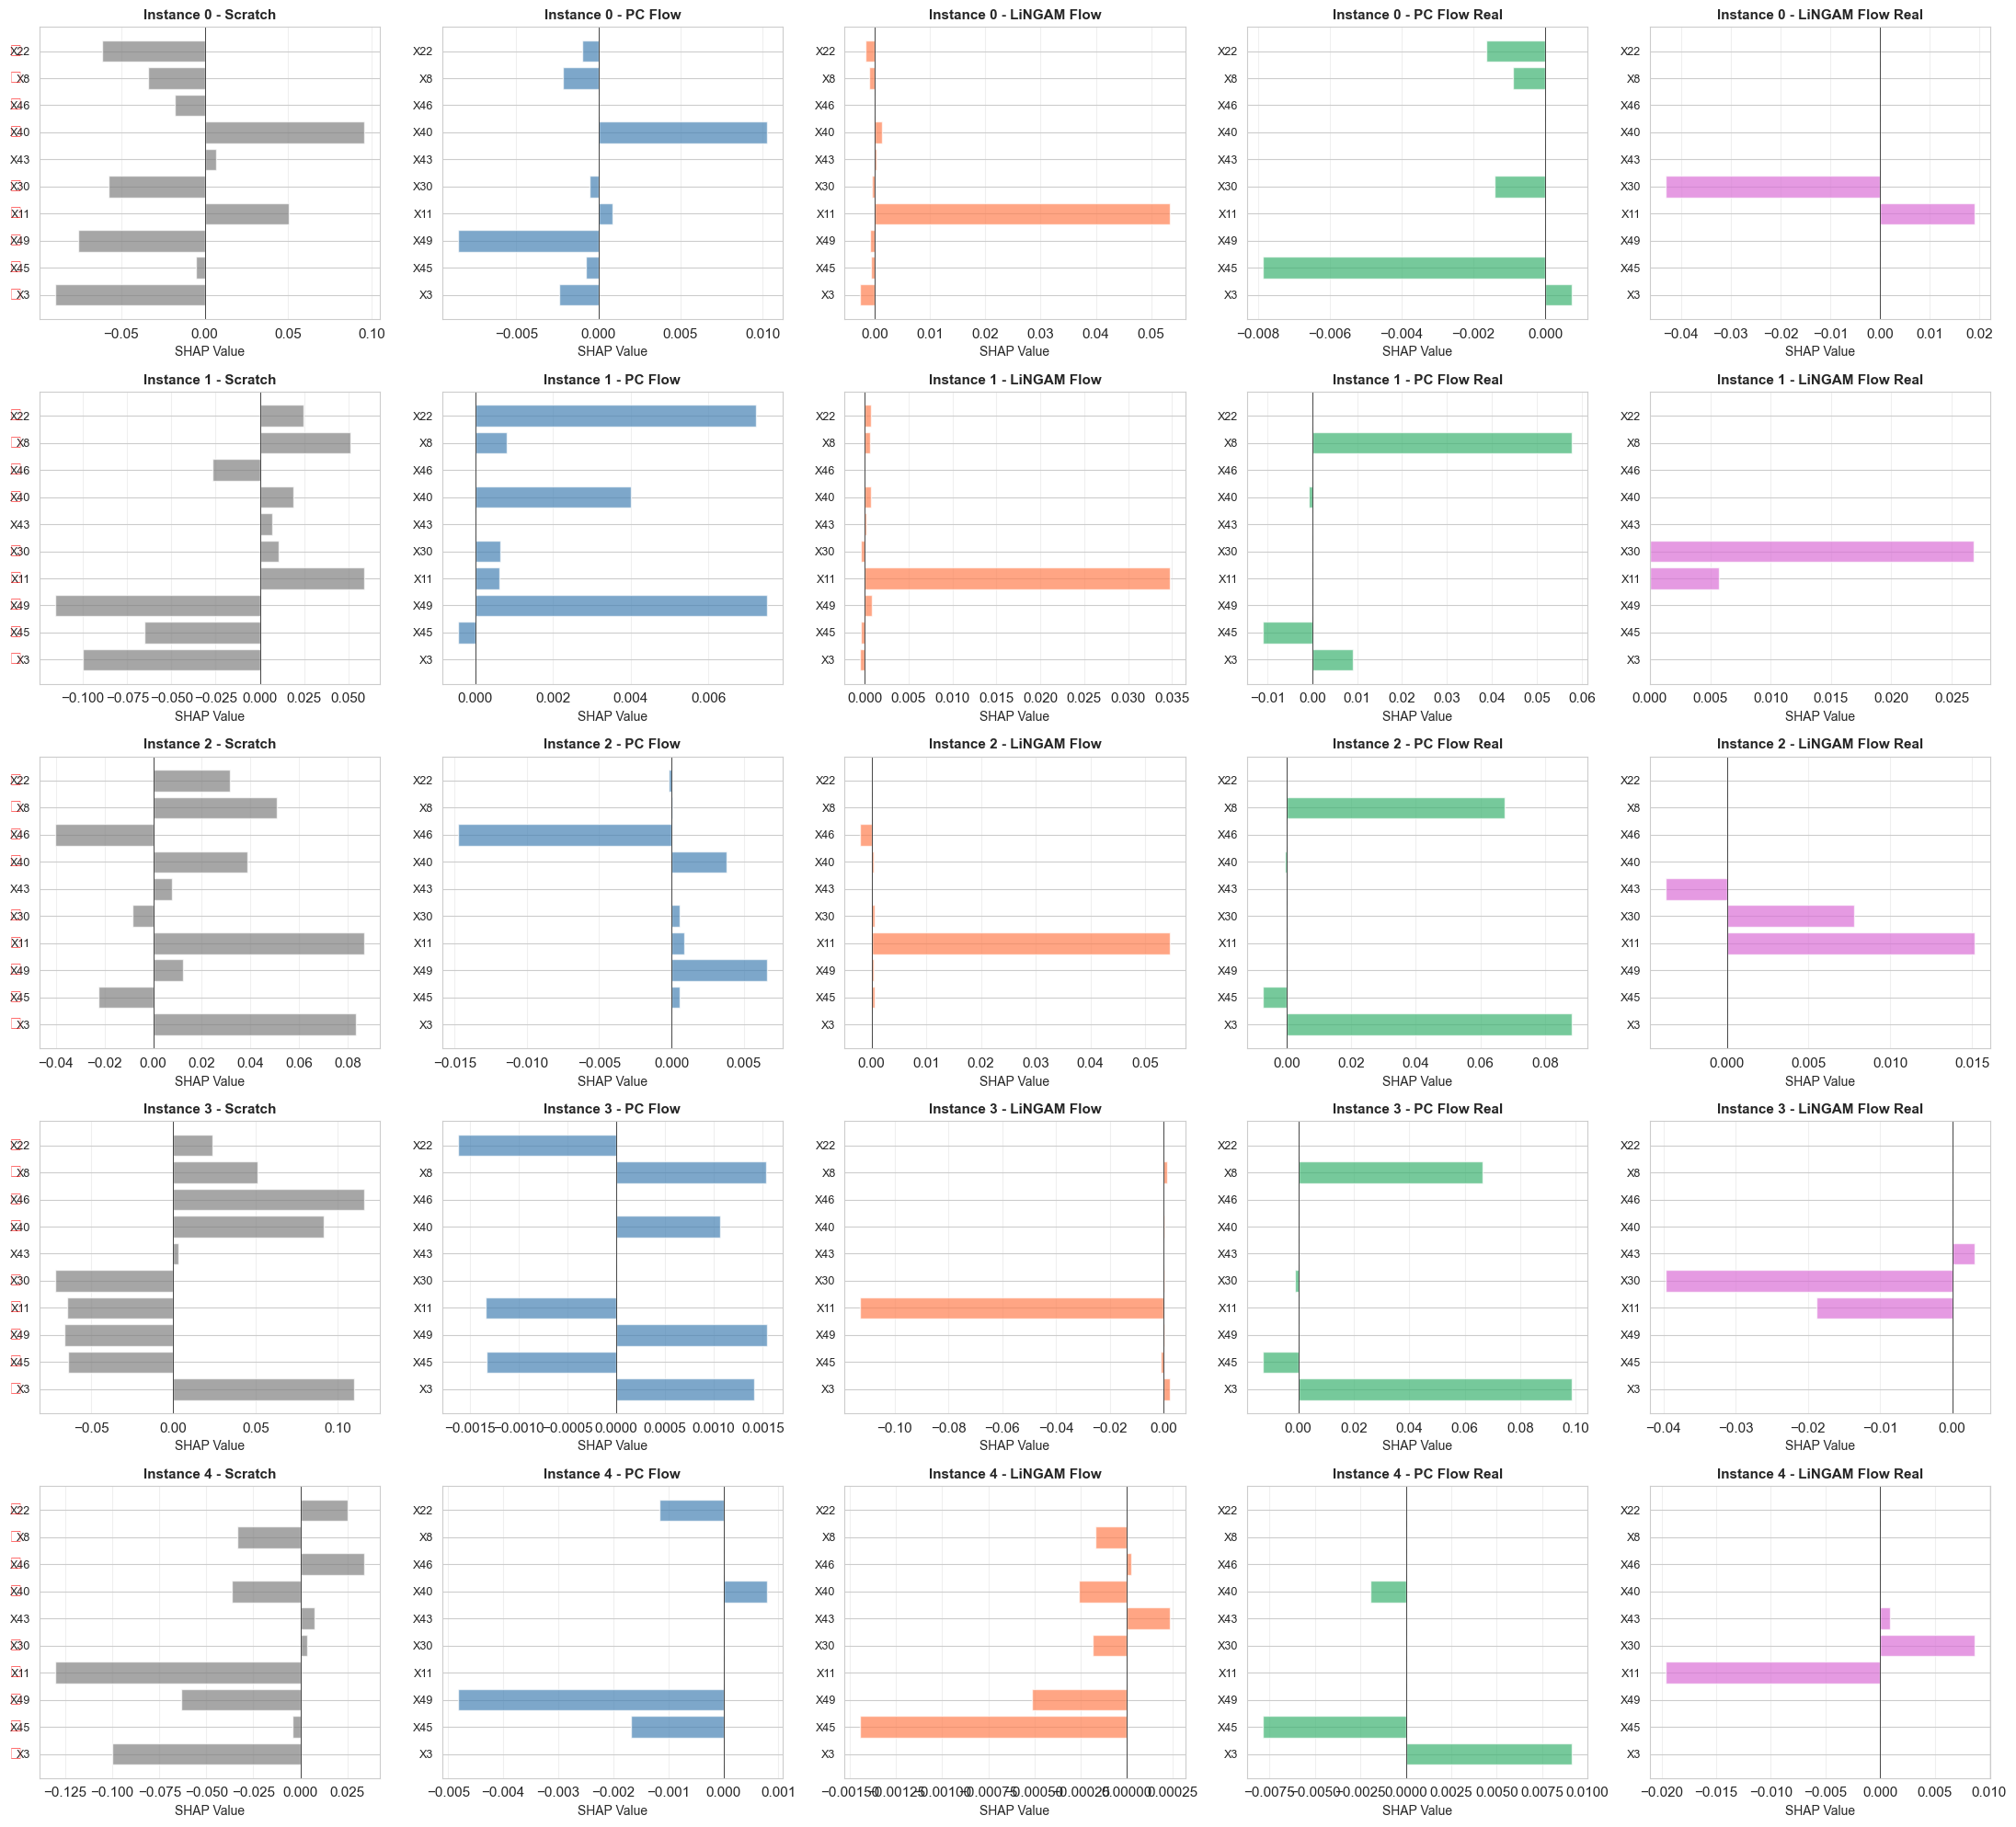

★ = True Y parent

This shows the top 10 features for specific test instances,
revealing how explanations can differ at the instance level.


In [29]:
# Show instance-level comparison for a few interesting cases
n_instances_to_show = 5

fig, axes = plt.subplots(n_instances_to_show, 5, figsize=(22, 4*n_instances_to_show))

for inst_idx in range(n_instances_to_show):
    # Get SHAP values for this instance across all features
    scratch_inst = scratch_values[inst_idx, :]
    pc_flow_inst = pc_flow_values[inst_idx, :]
    lingam_flow_inst = lingam_flow_values[inst_idx, :]
    pc_flow_real_inst = pc_flow_real_values[inst_idx, :]
    lingam_flow_real_inst = lingam_flow_real_values[inst_idx, :]
    
    # Get top 10 features for this instance
    # top_10_inst = np.argsort(np.abs(scratch_inst))[-10:][::-1]
    top_10_inst = top_10_indices
    top_10_features_inst = [feature_names[i] for i in top_10_inst]
    
    # Plot 1: Scratch values
    axes[inst_idx, 0].barh(range(10), scratch_inst[top_10_inst], color='gray', alpha=0.7)
    axes[inst_idx, 0].set_yticks(range(10))
    axes[inst_idx, 0].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 0].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 0].set_title(f'Instance {inst_idx} - Scratch', fontsize=11, fontweight='bold')
    axes[inst_idx, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 0].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 0].text(-0.05, i, '★', transform=axes[inst_idx, 0].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 2: PC Flow values
    axes[inst_idx, 1].barh(range(10), pc_flow_inst[top_10_inst], color='steelblue', alpha=0.7)
    axes[inst_idx, 1].set_yticks(range(10))
    axes[inst_idx, 1].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 1].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 1].set_title(f'Instance {inst_idx} - PC Flow', fontsize=11, fontweight='bold')
    axes[inst_idx, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 1].grid(True, alpha=0.3, axis='x')
    
    # Plot 3: LiNGAM Flow values
    axes[inst_idx, 2].barh(range(10), lingam_flow_inst[top_10_inst], color='coral', alpha=0.7)
    axes[inst_idx, 2].set_yticks(range(10))
    axes[inst_idx, 2].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 2].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 2].set_title(f'Instance {inst_idx} - LiNGAM Flow', fontsize=11, fontweight='bold')
    axes[inst_idx, 2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 2].grid(True, alpha=0.3, axis='x')
    
    # Plot 4: PC Flow Real values
    axes[inst_idx, 3].barh(range(10), pc_flow_real_inst[top_10_inst], color='mediumseagreen', alpha=0.7)
    axes[inst_idx, 3].set_yticks(range(10))
    axes[inst_idx, 3].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 3].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 3].set_title(f'Instance {inst_idx} - PC Flow Real', fontsize=11, fontweight='bold')
    axes[inst_idx, 3].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 3].grid(True, alpha=0.3, axis='x')
    
    # Plot 5: LiNGAM Flow Real values
    axes[inst_idx, 4].barh(range(10), lingam_flow_real_inst[top_10_inst], color='orchid', alpha=0.7)
    axes[inst_idx, 4].set_yticks(range(10))
    axes[inst_idx, 4].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 4].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 4].set_title(f'Instance {inst_idx} - LiNGAM Flow Real', fontsize=11, fontweight='bold')
    axes[inst_idx, 4].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 4].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("\nThis shows the top 10 features for specific test instances,")
print("revealing how explanations can differ at the instance level.")

### 13.2 Causal Shapley: Instance-Level Comparison

Examining how Causal Shapley values differ across specific test instances for Scratch, PC, and LiNGAM methods.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/827910547.py:62: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


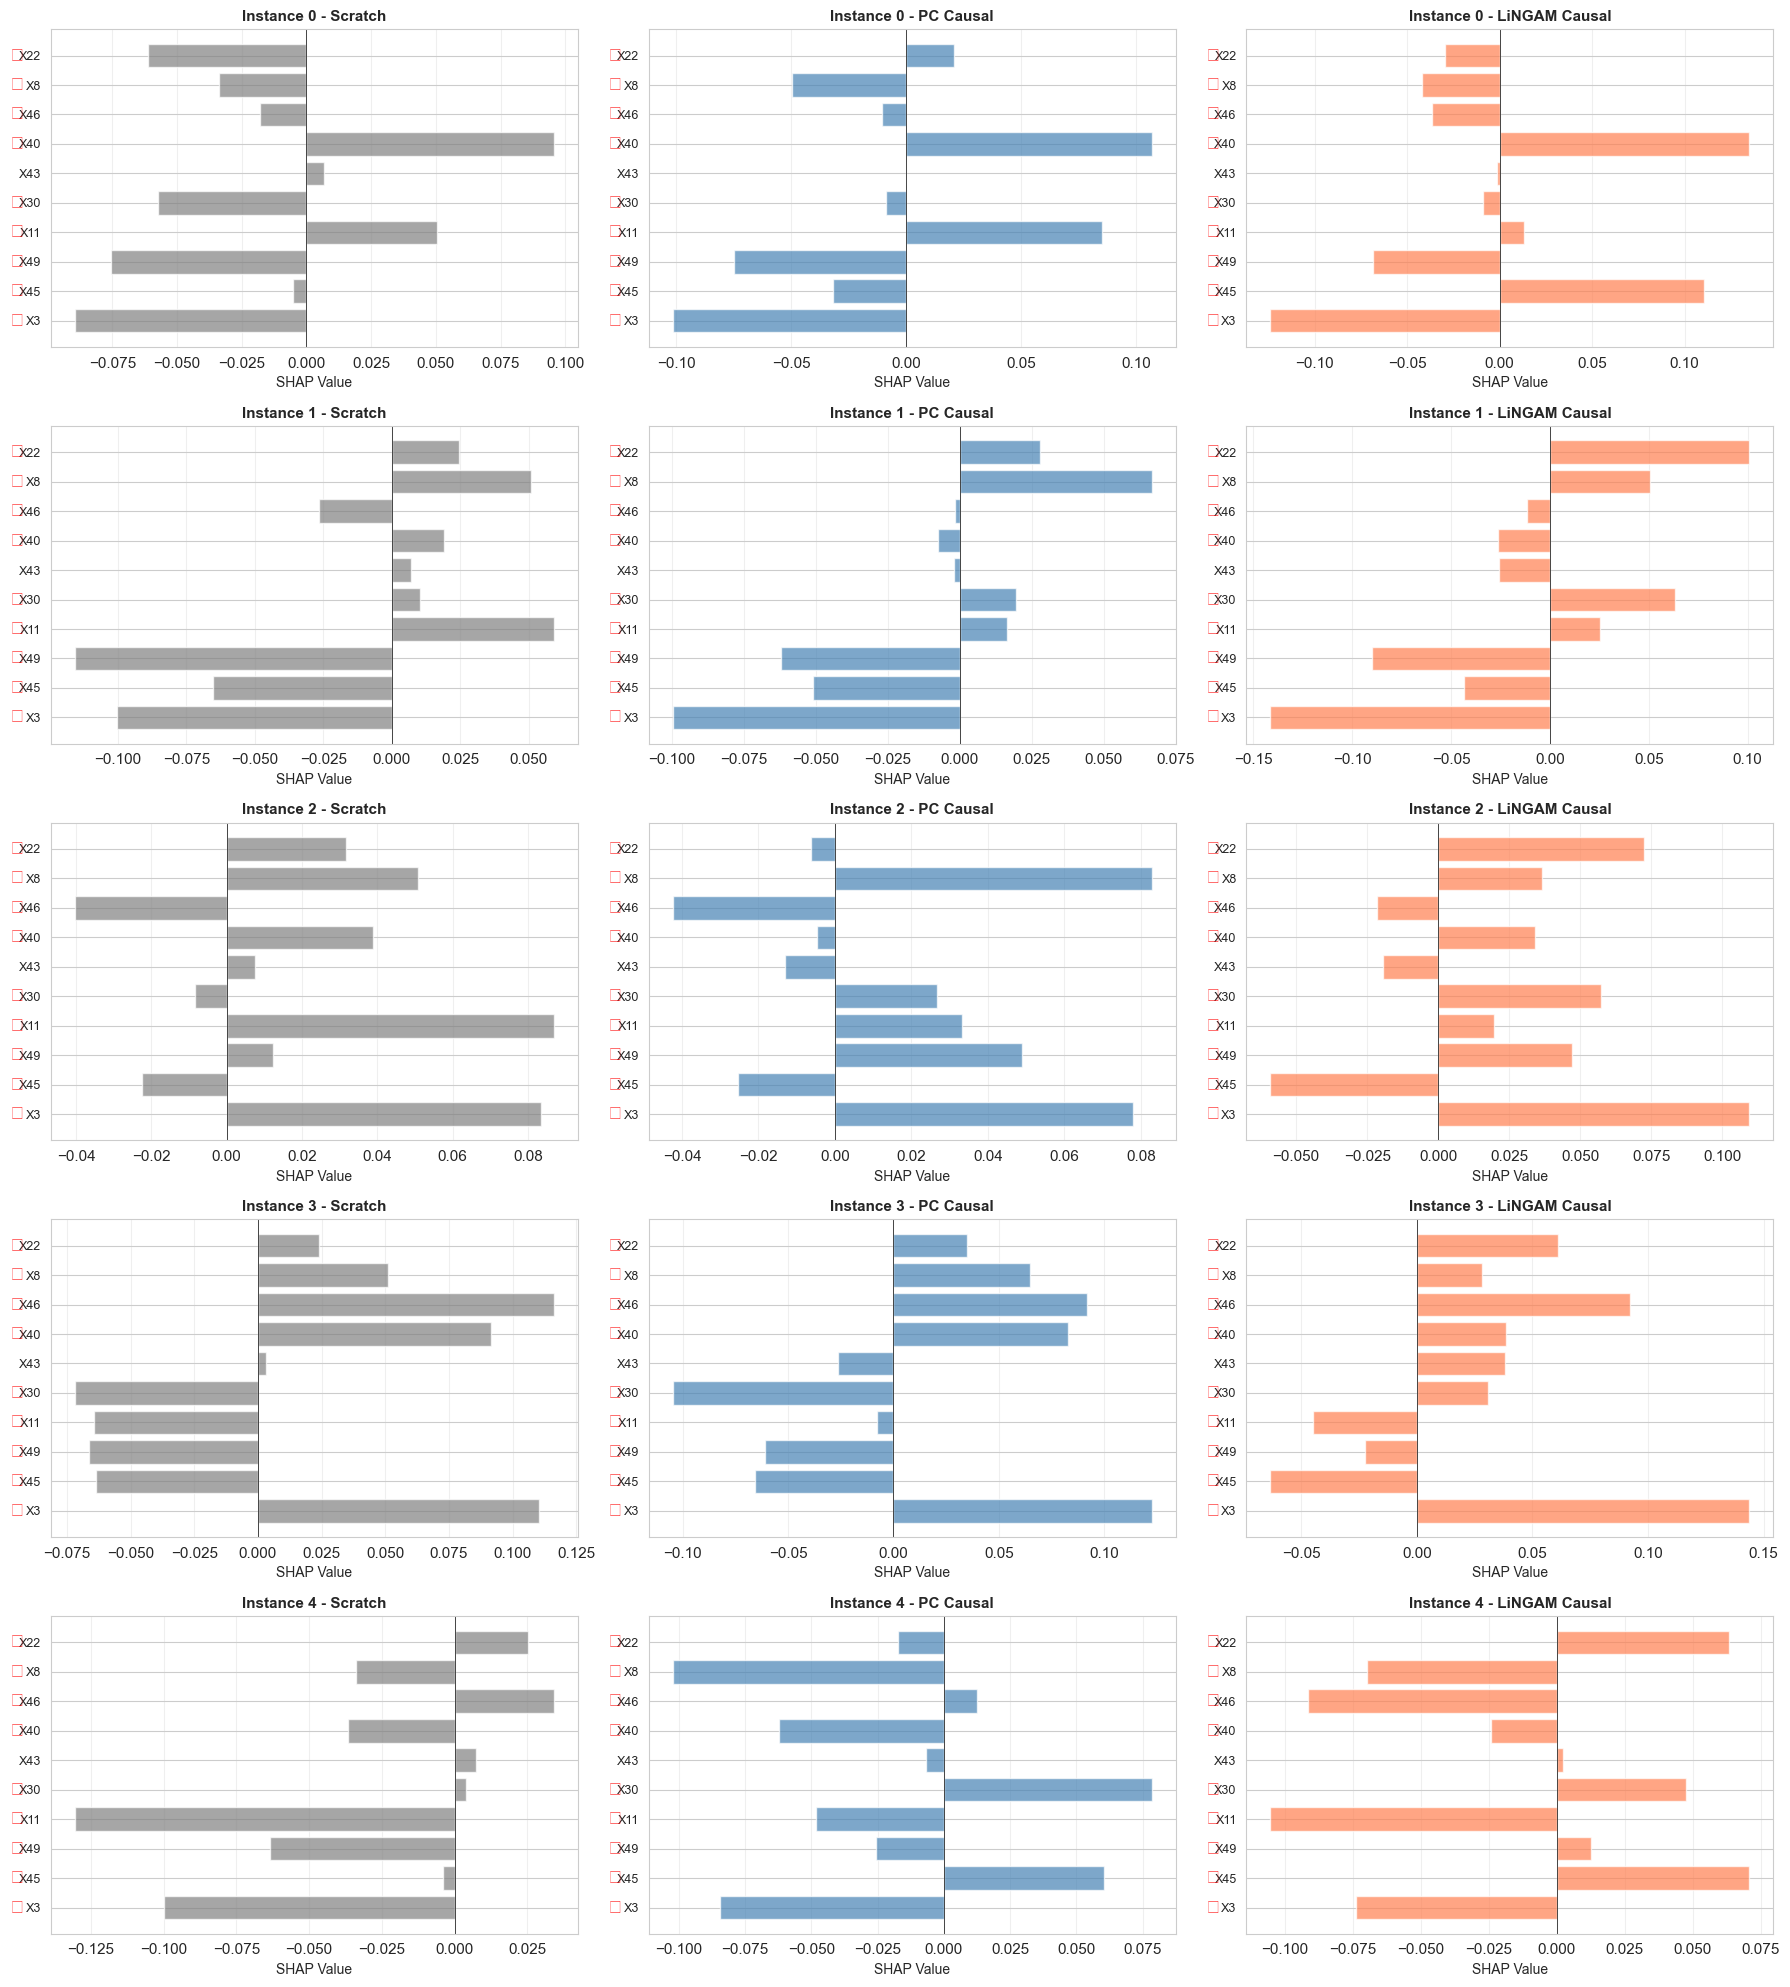

★ = True Y parent

This shows the top 10 features for specific test instances using Causal Shapley,
revealing how explanations can differ at the instance level across methods.


In [30]:
# Show instance-level comparison for Causal Shapley
n_instances_to_show = 5

fig, axes = plt.subplots(n_instances_to_show, 3, figsize=(18, 4*n_instances_to_show))

for inst_idx in range(n_instances_to_show):
    # Get SHAP values for this instance across all features
    scratch_inst = scratch_values[inst_idx, :]
    pc_causal_inst = pc_causal_values[inst_idx, :]
    lingam_causal_inst = lingam_causal_values[inst_idx, :]
    
    # Get top 10 features for this instance
    # top_10_inst = np.argsort(np.abs(scratch_inst))[-10:][::-1]
    top_10_inst = top_10_indices
    top_10_features_inst = [feature_names[i] for i in top_10_inst]
    
    # Plot 1: Scratch values
    axes[inst_idx, 0].barh(range(10), scratch_inst[top_10_inst], color='gray', alpha=0.7)
    axes[inst_idx, 0].set_yticks(range(10))
    axes[inst_idx, 0].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 0].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 0].set_title(f'Instance {inst_idx} - Scratch', fontsize=11, fontweight='bold')
    axes[inst_idx, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 0].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 0].text(-0.05, i, '★', transform=axes[inst_idx, 0].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 2: PC Causal values
    axes[inst_idx, 1].barh(range(10), pc_causal_inst[top_10_inst], color='steelblue', alpha=0.7)
    axes[inst_idx, 1].set_yticks(range(10))
    axes[inst_idx, 1].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 1].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 1].set_title(f'Instance {inst_idx} - PC Causal', fontsize=11, fontweight='bold')
    axes[inst_idx, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 1].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 1].text(-0.05, i, '★', transform=axes[inst_idx, 1].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 3: LiNGAM Causal values
    axes[inst_idx, 2].barh(range(10), lingam_causal_inst[top_10_inst], color='coral', alpha=0.7)
    axes[inst_idx, 2].set_yticks(range(10))
    axes[inst_idx, 2].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 2].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 2].set_title(f'Instance {inst_idx} - LiNGAM Causal', fontsize=11, fontweight='bold')
    axes[inst_idx, 2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 2].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 2].text(-0.05, i, '★', transform=axes[inst_idx, 2].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')

plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("\nThis shows the top 10 features for specific test instances using Causal Shapley,")
print("revealing how explanations can differ at the instance level across methods.")

### 13.1 Asymmetric Shapley: Instance-Level Comparison

Examining how Asymmetric Shapley values differ across specific test instances for Scratch, PC, and LiNGAM methods.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/195598440.py:62: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


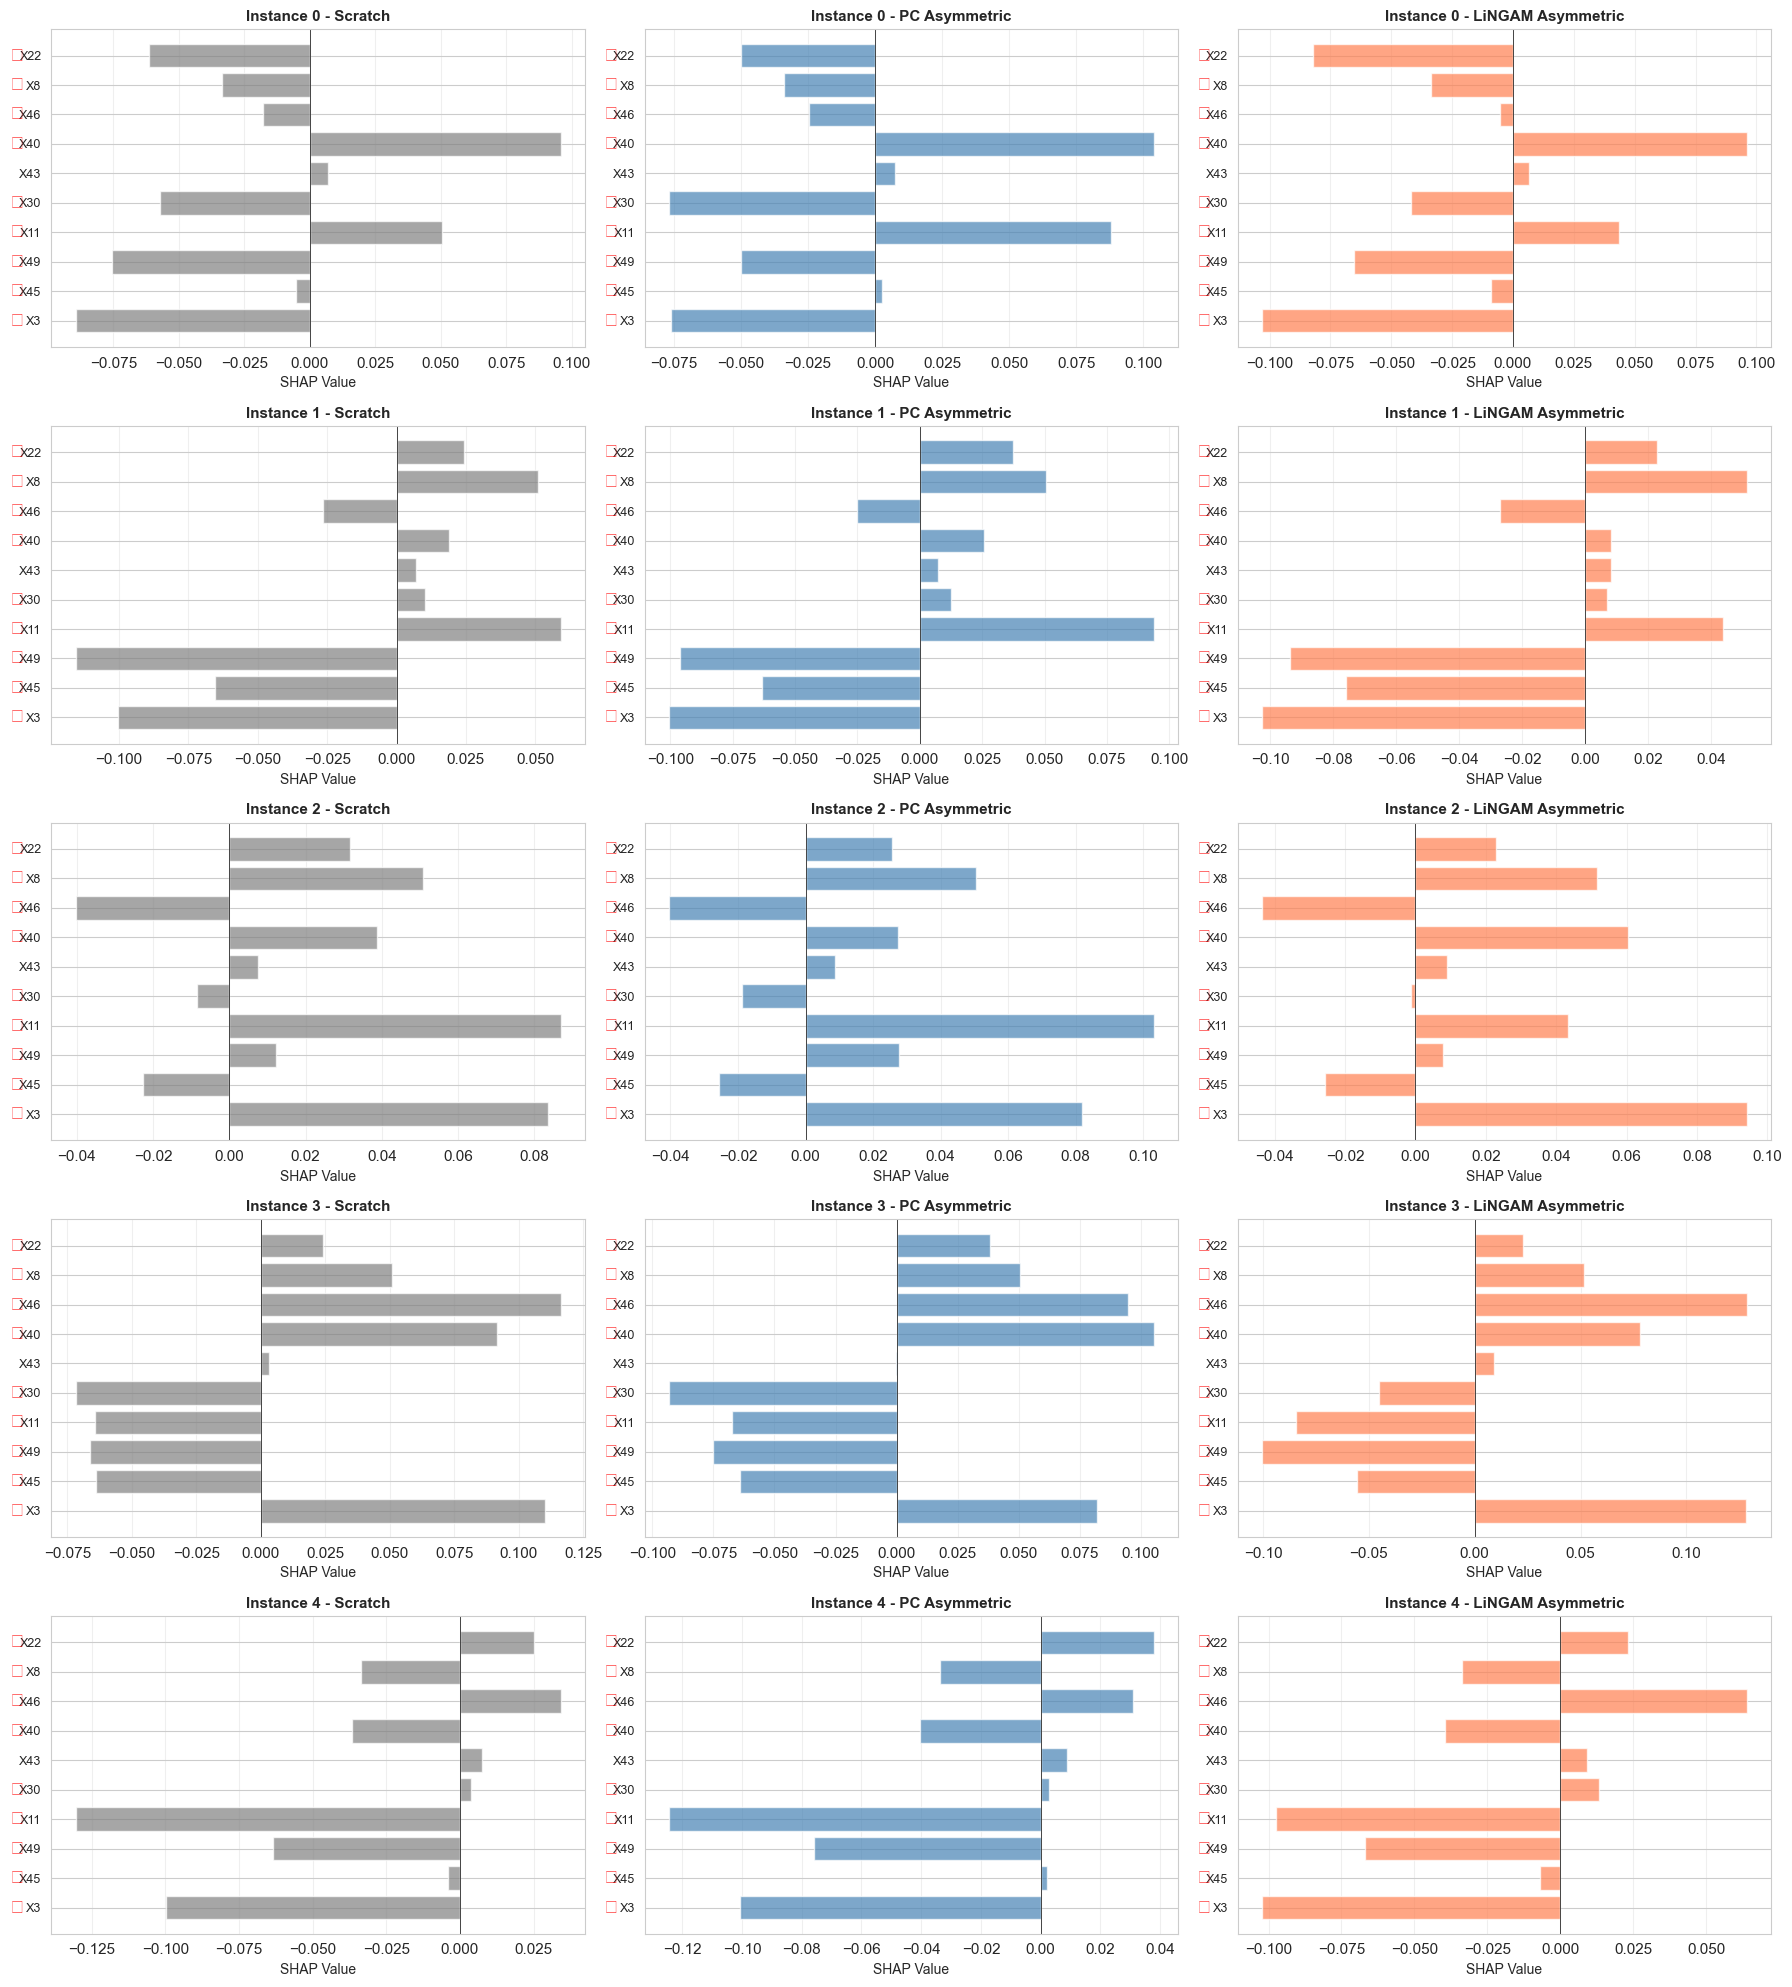

★ = True Y parent

This shows the top 10 features for specific test instances using Asymmetric Shapley,
revealing how explanations can differ at the instance level across methods.


In [31]:
# Show instance-level comparison for Asymmetric Shapley
n_instances_to_show = 5

fig, axes = plt.subplots(n_instances_to_show, 3, figsize=(18, 4*n_instances_to_show))

for inst_idx in range(n_instances_to_show):
    # Get SHAP values for this instance across all features
    scratch_inst = scratch_values[inst_idx, :]
    pc_asym_inst = pc_asym_values[inst_idx, :]
    lingam_asym_inst = lingam_asym_values[inst_idx, :]
    
    # Get top 10 features for this instance
    # top_10_inst = np.argsort(np.abs(scratch_inst))[-10:][::-1]
    top_10_inst = top_10_indices
    top_10_features_inst = [feature_names[i] for i in top_10_inst]
    
    # Plot 1: Scratch values
    axes[inst_idx, 0].barh(range(10), scratch_inst[top_10_inst], color='gray', alpha=0.7)
    axes[inst_idx, 0].set_yticks(range(10))
    axes[inst_idx, 0].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 0].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 0].set_title(f'Instance {inst_idx} - Scratch', fontsize=11, fontweight='bold')
    axes[inst_idx, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 0].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 0].text(-0.05, i, '★', transform=axes[inst_idx, 0].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 2: PC Asymmetric values
    axes[inst_idx, 1].barh(range(10), pc_asym_inst[top_10_inst], color='steelblue', alpha=0.7)
    axes[inst_idx, 1].set_yticks(range(10))
    axes[inst_idx, 1].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 1].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 1].set_title(f'Instance {inst_idx} - PC Asymmetric', fontsize=11, fontweight='bold')
    axes[inst_idx, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 1].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 1].text(-0.05, i, '★', transform=axes[inst_idx, 1].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 3: LiNGAM Asymmetric values
    axes[inst_idx, 2].barh(range(10), lingam_asym_inst[top_10_inst], color='coral', alpha=0.7)
    axes[inst_idx, 2].set_yticks(range(10))
    axes[inst_idx, 2].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 2].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 2].set_title(f'Instance {inst_idx} - LiNGAM Asymmetric', fontsize=11, fontweight='bold')
    axes[inst_idx, 2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 2].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 2].text(-0.05, i, '★', transform=axes[inst_idx, 2].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')

plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("\nThis shows the top 10 features for specific test instances using Asymmetric Shapley,")
print("revealing how explanations can differ at the instance level across methods.")

In [32]:
scratch_inst[top_10_inst]

array([-0.09984803, -0.00399731, -0.06355121, -0.13045879,  0.00380794,
        0.00747362, -0.03666972,  0.03417233, -0.03372192,  0.02524075])

In [33]:
pc_asym_inst[top_10_inst]

array([-0.10074023,  0.00213524, -0.0759221 , -0.12455729,  0.0028157 ,
        0.00881838, -0.04037039,  0.03101944, -0.03372192,  0.03793652])

In [34]:
lingam_asym_inst[top_10_inst]

array([-0.10221669, -0.00688986, -0.06689336, -0.09730238,  0.01317679,
        0.0091734 , -0.03961006,  0.0640341 , -0.03372192,  0.0232438 ])

## Conclusions

Based on the analysis above, focusing on **causally relevant features** (those in the discovered causal DAG), we can observe:

1. **Causal Feature Focus**: By filtering to features in the causal graph, we ensure our analysis examines truly relevant features rather than spurious correlations. This provides more meaningful comparisons between methods.

2. **Top Causal Feature Identification**: The top 10 causal features identified by different methods show varying levels of agreement, revealing how different Shapley approaches interpret causal structure.

3. **PC vs LiNGAM**: The correlation and agreement between PC and LiNGAM-based methods varies across different Shapley methods (Asymmetric, Causal, Flow, Flow Real), with stronger agreement when both methods identify similar causal structures.

4. **Flow vs Flow Real Comparison** (Section 15): 
   - Direct comparison reveals how the two flow-based methods differ
   - Instance-level correlations show agreement at granular level
   - Precision@K analysis shows which method better identifies true parents among causal features

5. **Flow Methods**: ShapleyFlow and ShapleyFlow Real provide distinct perspectives compared to Asymmetric and Causal Shapley, with varying abilities to separate true Y parents from non-parents within the causal feature set.

6. **True Parent Detection**: Among causal features, different methods show different abilities to separate true Y parents from other causal features, as shown in the distribution comparison (Section 7) and performance metrics.

7. **Instance-Level Analysis**: Sections 11 and 13 reveal how methods can disagree significantly at the instance level even when global feature importance is similar, particularly for features with complex causal relationships.

Next steps:
- Compare causal vs non-causal feature analysis to quantify the benefit of causal filtering
- Analyze the causal graphs discovered by PC and LiNGAM in more detail
- Investigate why certain causal features rank differently across methods
- Examine specific instances where methods disagree most on causal feature importance
- Compare performance across different datasets and model types

## 14. SHAP Dependence Plots: Feature Value vs SHAP Value

For each of the top 10 **causal features** (filtered to those in the causal DAG), we create detailed dependence plots showing:
- **Y-axis**: SHAP value for each instance
- **X-axis**: Actual feature value for each instance
- **Layout**: Each feature gets a row, with columns comparing Scratch, PC, and LiNGAM

This reveals how SHAP values vary with feature values across different methods for causally relevant features.

### 14.1 Asymmetric Shapley: Feature Dependence Plots

Test data shape: (200, 50)
SHAP values shape: (100, 50)
Using first 100 test samples for plotting


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/411667533.py:95: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


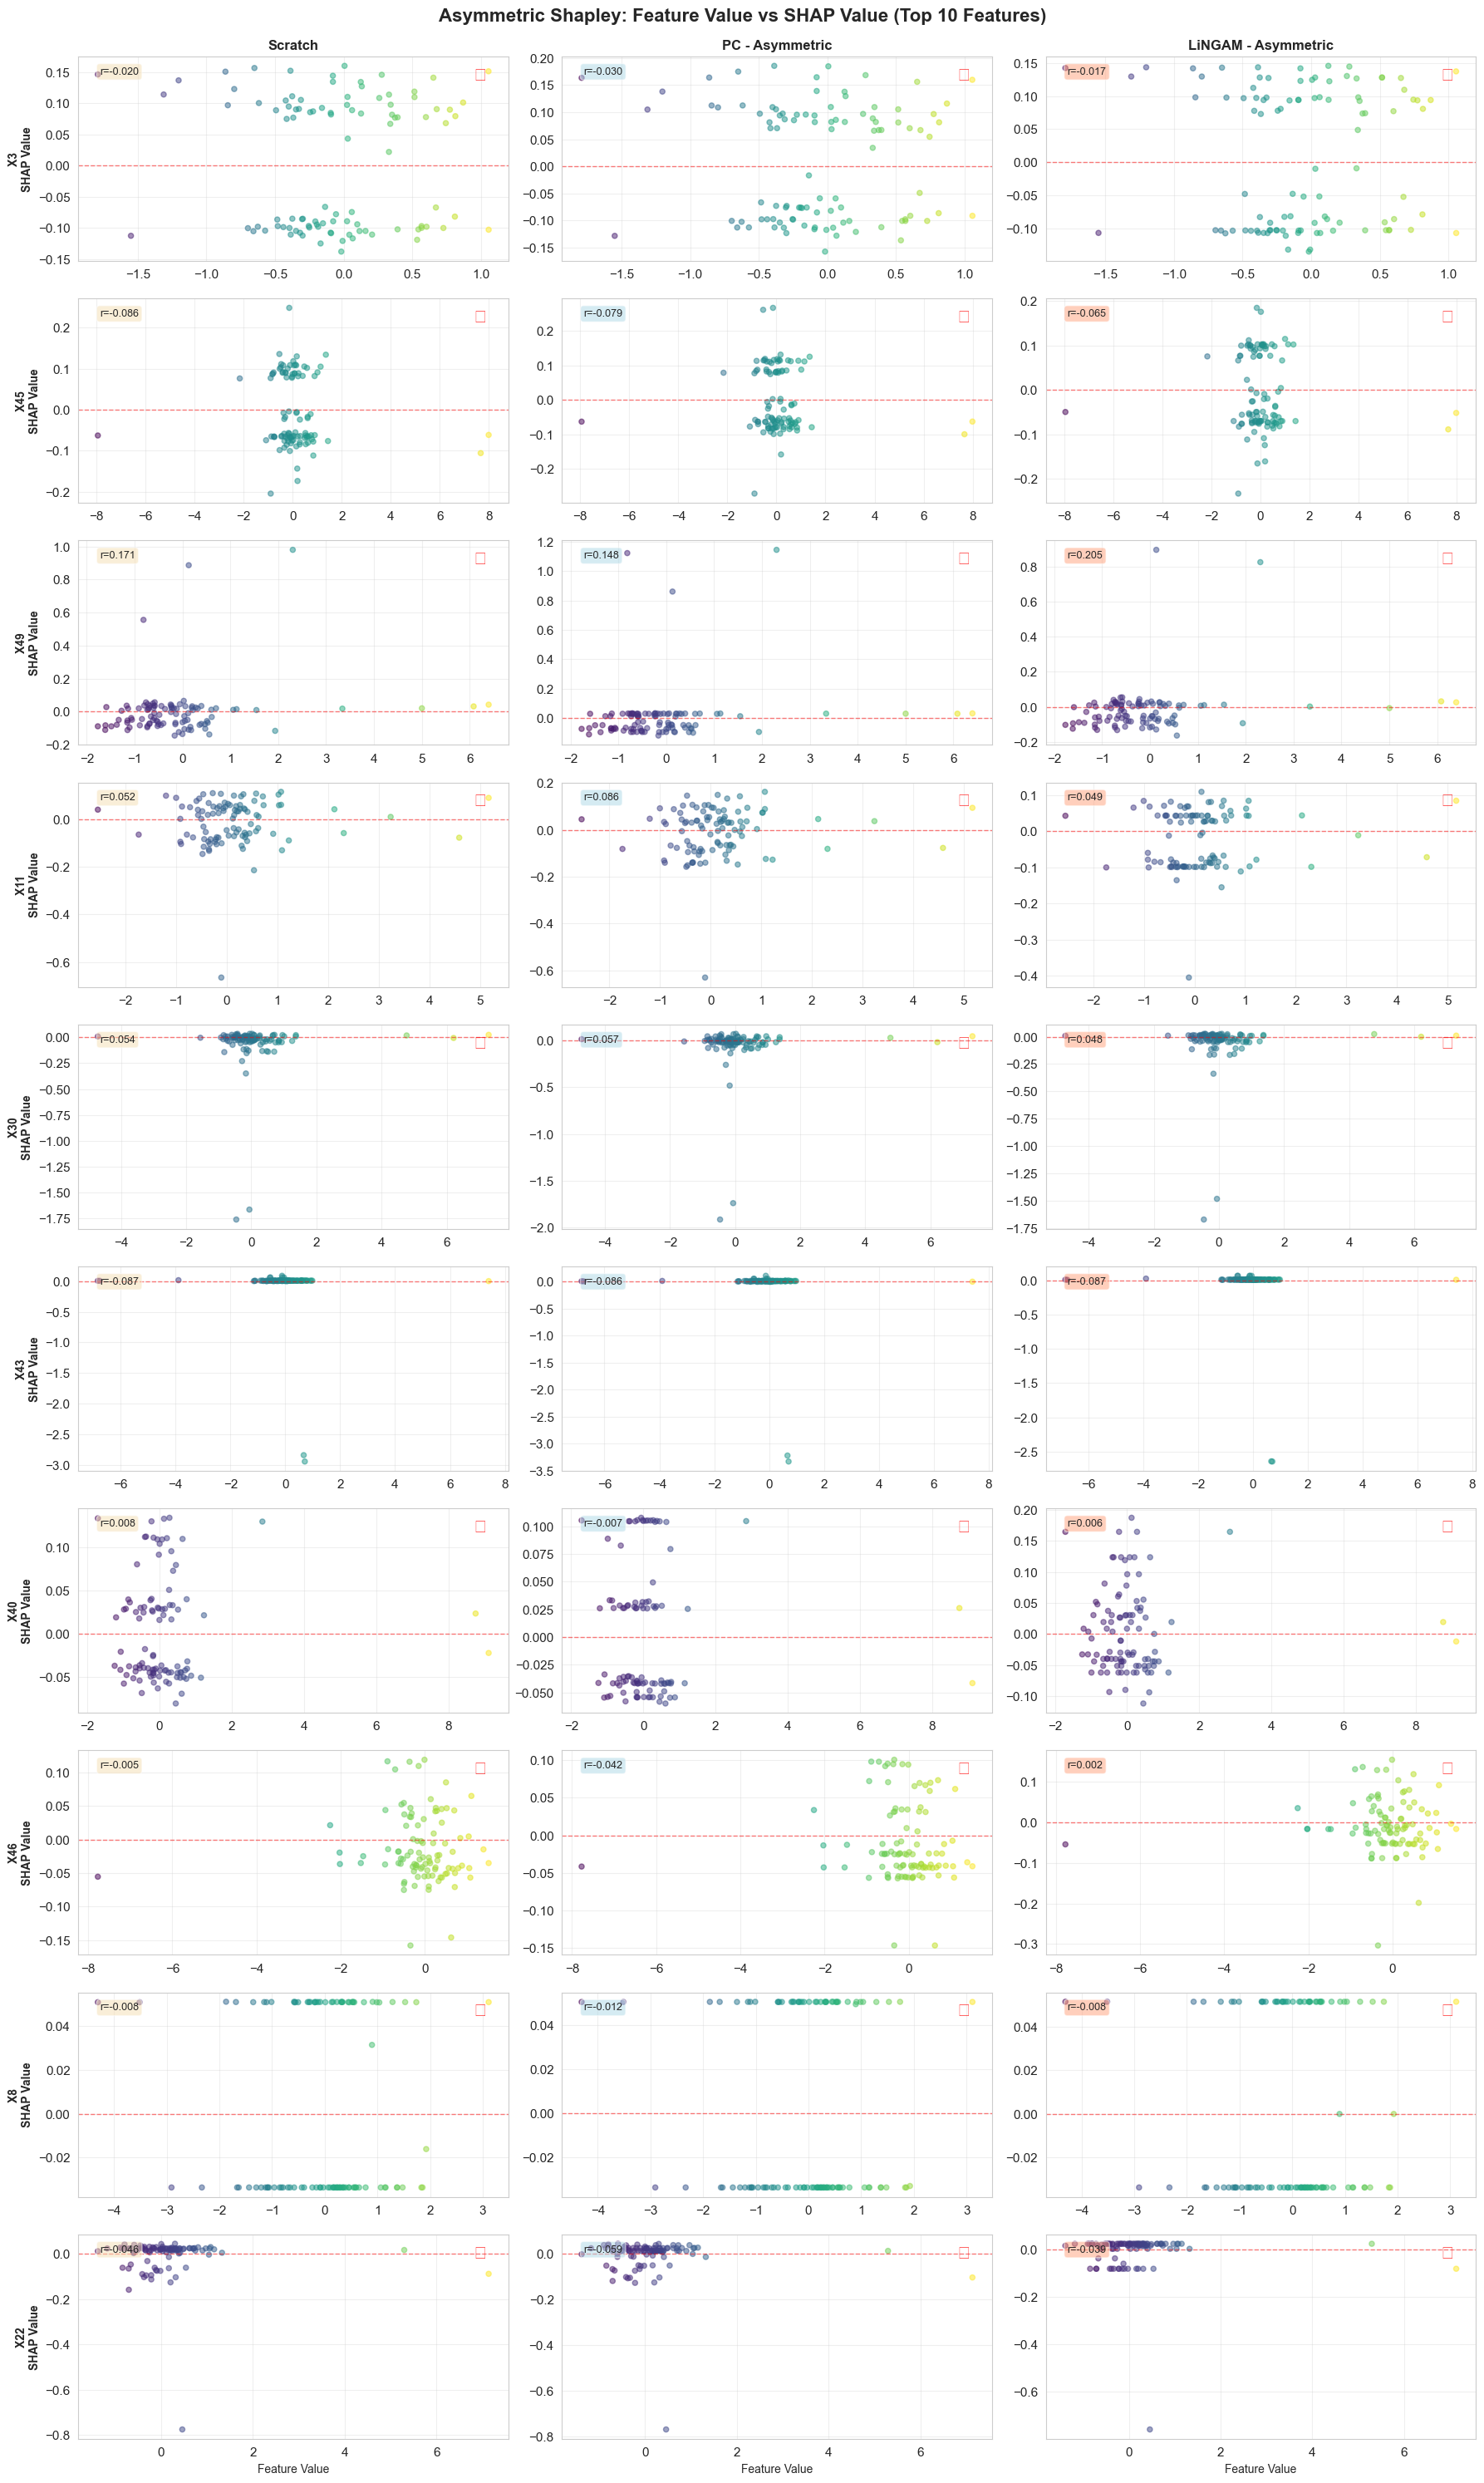

★ = True Y parent
r = Pearson correlation between feature value and SHAP value
Each point represents one test instance


In [35]:
# Create comprehensive dependence plots for Asymmetric Shapley
# Each row is a feature, columns are: Scratch, PC_Asym, LiNGAM_Asym

# First, load test data to match SHAP values
test_path = PROCESSED_DIR / f"{DATASET}_test.parquet"
test_data = pd.read_parquet(test_path)
X_test = test_data.drop(columns=['Y'])

# Match the number of samples with SHAP values
n_samples_shap = scratch_values.shape[0]
X_test_matched = X_test.iloc[:n_samples_shap, :]

print(f"Test data shape: {X_test.shape}")
print(f"SHAP values shape: {scratch_values.shape}")
print(f"Using first {n_samples_shap} test samples for plotting")

n_features_to_plot = 10  # Top 10 features
n_cols = 3  # Scratch, PC, LiNGAM

fig, axes = plt.subplots(n_features_to_plot, n_cols, figsize=(18, 3*n_features_to_plot))

for feat_idx, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    is_true_parent = idx in true_parents
    
    # Get feature values from test data (to match SHAP values)
    feature_values = X_test_matched.iloc[:, idx].values
    
    # Get SHAP values for this feature
    scratch_shap = scratch_values[:, idx]
    pc_asym_shap = pc_asym_values[:, idx]
    lingam_asym_shap = lingam_asym_values[:, idx]
    
    # Plot 1: Scratch
    ax = axes[feat_idx, 0]
    scatter = ax.scatter(feature_values, scratch_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel(f'{fname}\nSHAP Value', fontsize=10, fontweight='bold')
    if feat_idx == 0:
        ax.set_title('Scratch', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_scratch = np.corrcoef(feature_values, scratch_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_scratch:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Mark if true parent
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 2: PC Asymmetric
    ax = axes[feat_idx, 1]
    scatter = ax.scatter(feature_values, pc_asym_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('PC - Asymmetric', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_pc = np.corrcoef(feature_values, pc_asym_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_pc:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 3: LiNGAM Asymmetric
    ax = axes[feat_idx, 2]
    scatter = ax.scatter(feature_values, lingam_asym_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('LiNGAM - Asymmetric', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_lingam = np.corrcoef(feature_values, lingam_asym_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_lingam:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')

plt.suptitle('Asymmetric Shapley: Feature Value vs SHAP Value (Top 10 Features)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("r = Pearson correlation between feature value and SHAP value")
print("Each point represents one test instance")

### 14.2 Causal Shapley: Feature Dependence Plots

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/1609867622.py:79: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


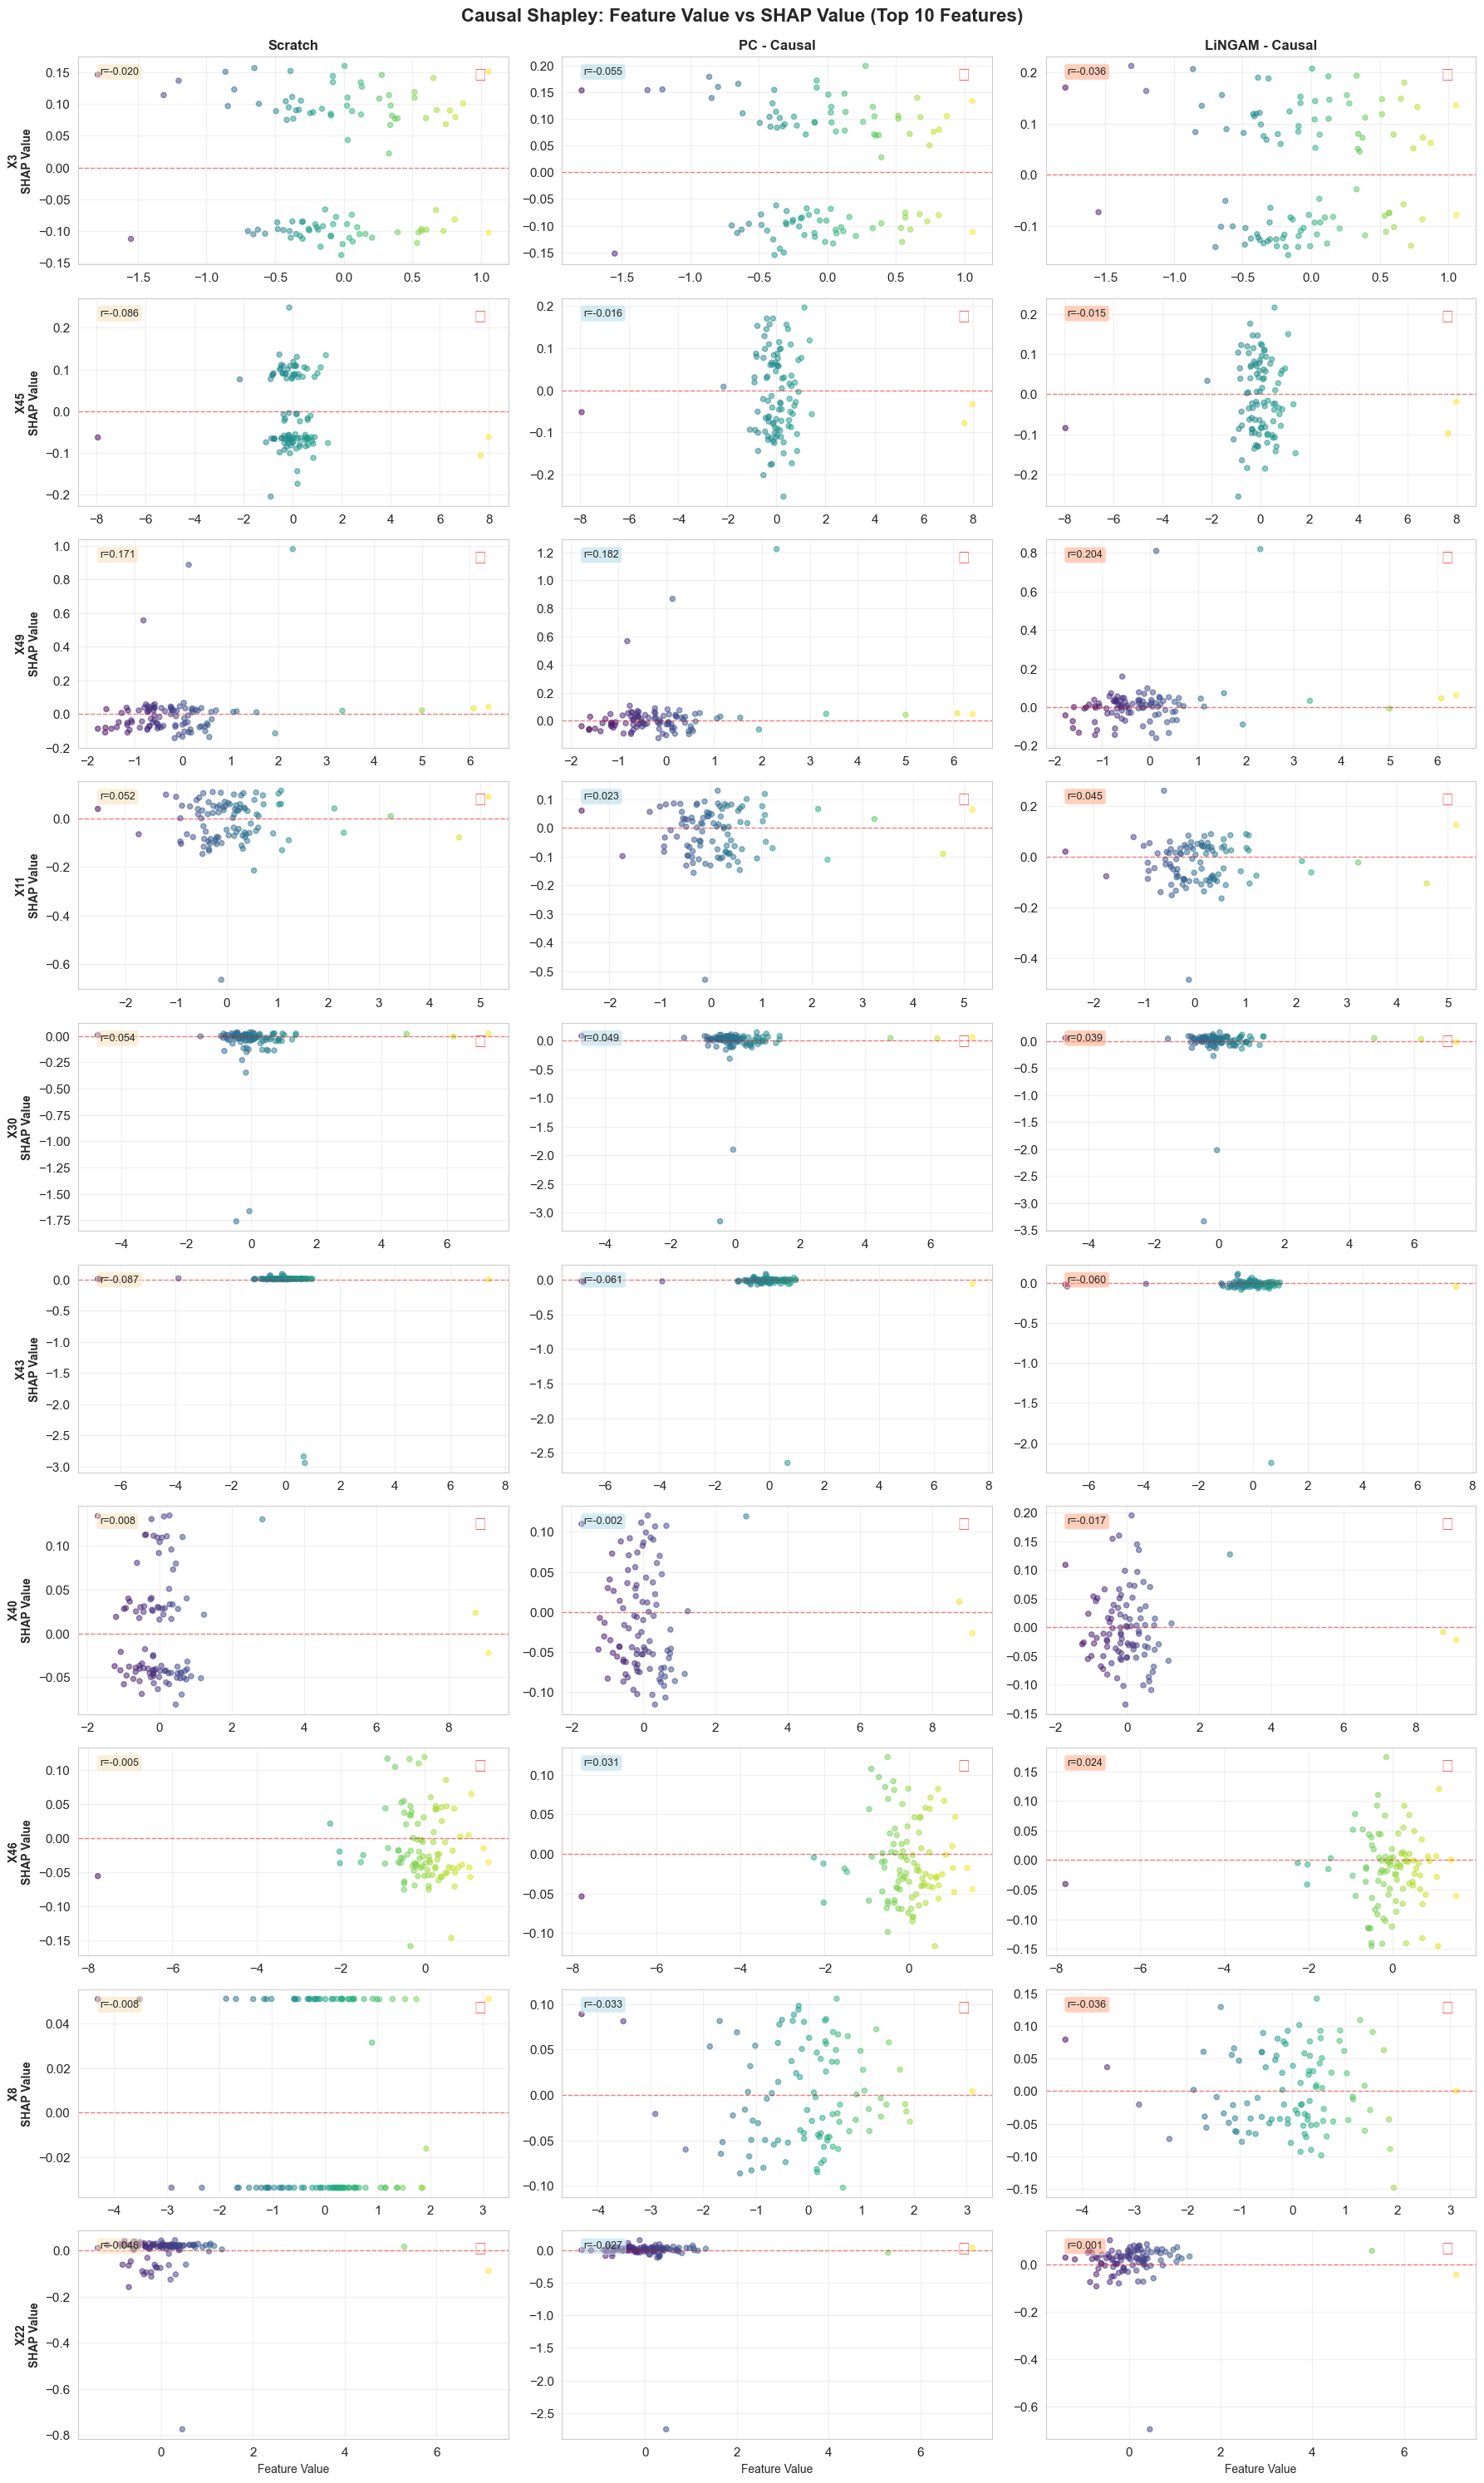

★ = True Y parent
r = Pearson correlation between feature value and SHAP value
Each point represents one test instance


In [36]:
# Create comprehensive dependence plots for Causal Shapley
# Each row is a feature, columns are: Scratch, PC_Causal, LiNGAM_Causal

fig, axes = plt.subplots(n_features_to_plot, n_cols, figsize=(18, 3*n_features_to_plot))

for feat_idx, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    is_true_parent = idx in true_parents
    
    # Get feature values from test data (to match SHAP values)
    feature_values = X_test_matched.iloc[:, idx].values
    
    # Get SHAP values for this feature
    scratch_shap = scratch_values[:, idx]
    pc_causal_shap = pc_causal_values[:, idx]
    lingam_causal_shap = lingam_causal_values[:, idx]
    
    # Plot 1: Scratch
    ax = axes[feat_idx, 0]
    scatter = ax.scatter(feature_values, scratch_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel(f'{fname}\nSHAP Value', fontsize=10, fontweight='bold')
    if feat_idx == 0:
        ax.set_title('Scratch', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_scratch = np.corrcoef(feature_values, scratch_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_scratch:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Mark if true parent
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 2: PC Causal
    ax = axes[feat_idx, 1]
    scatter = ax.scatter(feature_values, pc_causal_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('PC - Causal', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_pc = np.corrcoef(feature_values, pc_causal_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_pc:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 3: LiNGAM Causal
    ax = axes[feat_idx, 2]
    scatter = ax.scatter(feature_values, lingam_causal_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('LiNGAM - Causal', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_lingam = np.corrcoef(feature_values, lingam_causal_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_lingam:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')

plt.suptitle('Causal Shapley: Feature Value vs SHAP Value (Top 10 Features)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("r = Pearson correlation between feature value and SHAP value")
print("Each point represents one test instance")

### 14.3 ShapleyFlow: Feature Dependence Plots

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/1603124991.py:79: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


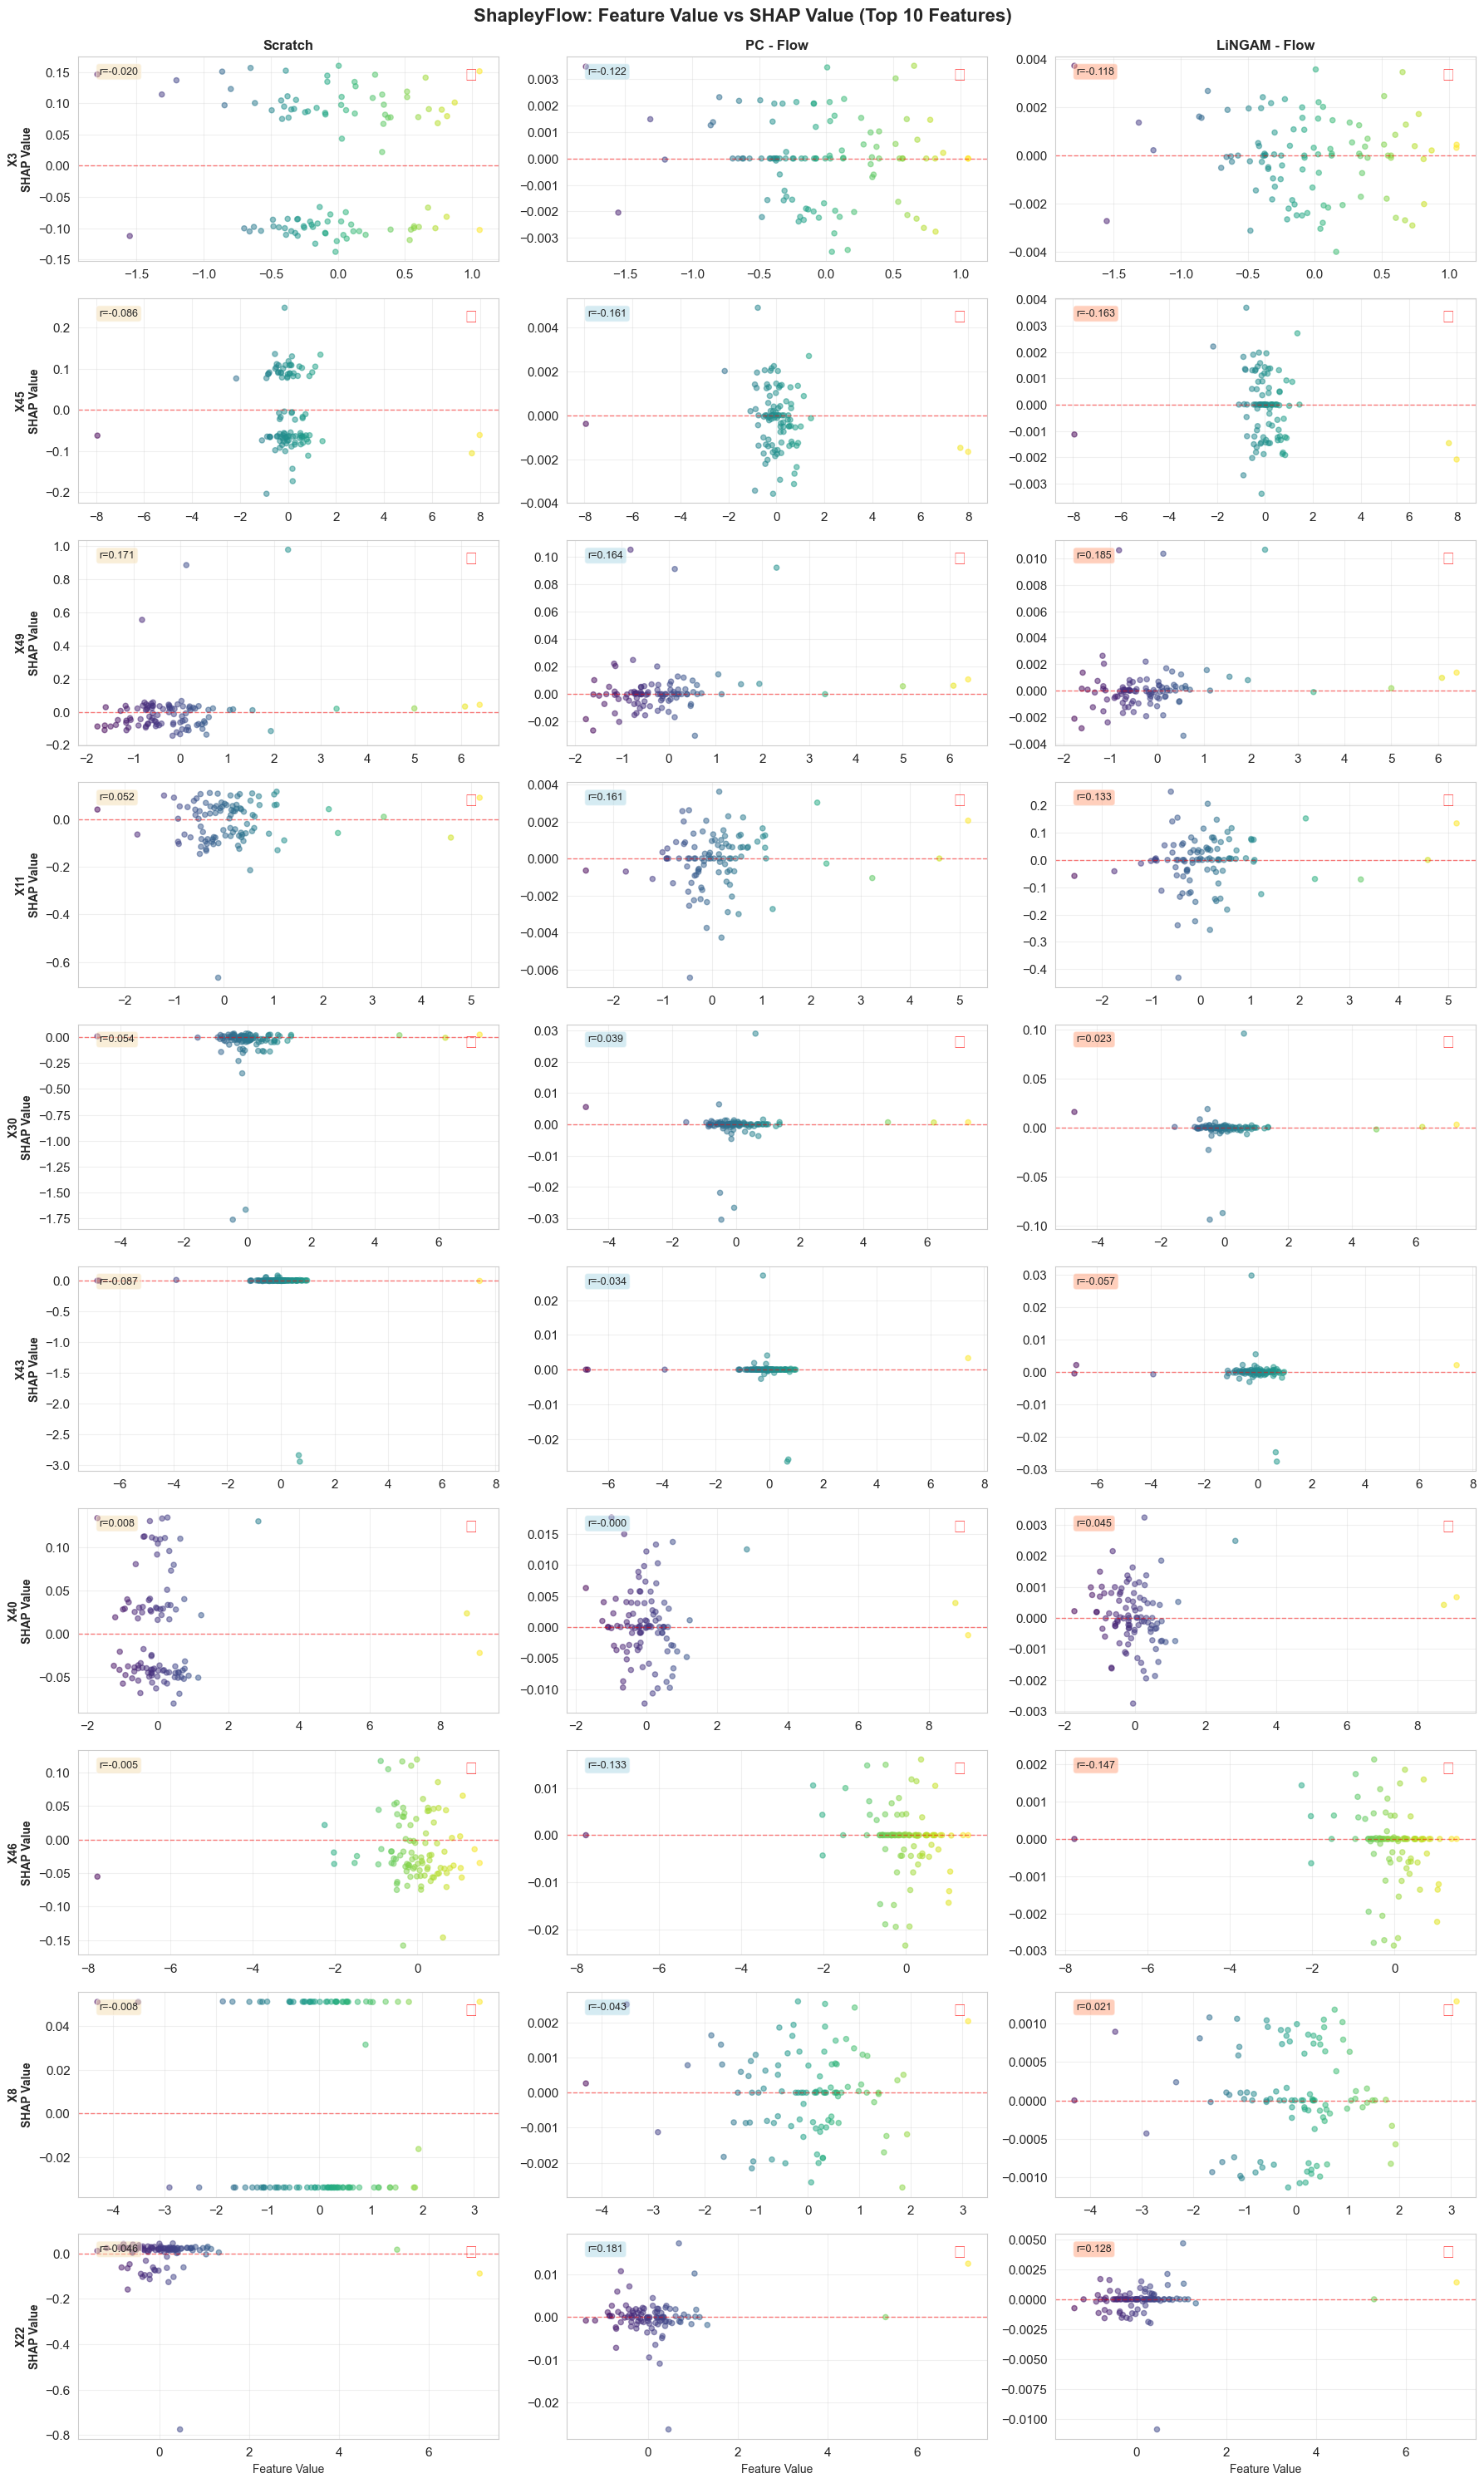

★ = True Y parent
r = Pearson correlation between feature value and SHAP value
Each point represents one test instance


In [37]:
# Create comprehensive dependence plots for ShapleyFlow
# Each row is a feature, columns are: Scratch, PC_Flow, LiNGAM_Flow

fig, axes = plt.subplots(n_features_to_plot, n_cols, figsize=(18, 3*n_features_to_plot))

for feat_idx, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    is_true_parent = idx in true_parents
    
    # Get feature values from test data (to match SHAP values)
    feature_values = X_test_matched.iloc[:, idx].values
    
    # Get SHAP values for this feature
    scratch_shap = scratch_values[:, idx]
    pc_flow_shap = pc_flow_values[:, idx]
    lingam_flow_shap = lingam_flow_values[:, idx]
    
    # Plot 1: Scratch
    ax = axes[feat_idx, 0]
    scatter = ax.scatter(feature_values, scratch_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel(f'{fname}\nSHAP Value', fontsize=10, fontweight='bold')
    if feat_idx == 0:
        ax.set_title('Scratch', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_scratch = np.corrcoef(feature_values, scratch_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_scratch:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Mark if true parent
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 2: PC Flow
    ax = axes[feat_idx, 1]
    scatter = ax.scatter(feature_values, pc_flow_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('PC - Flow', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_pc = np.corrcoef(feature_values, pc_flow_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_pc:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 3: LiNGAM Flow
    ax = axes[feat_idx, 2]
    scatter = ax.scatter(feature_values, lingam_flow_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('LiNGAM - Flow', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_lingam = np.corrcoef(feature_values, lingam_flow_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_lingam:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')

plt.suptitle('ShapleyFlow: Feature Value vs SHAP Value (Top 10 Features)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("r = Pearson correlation between feature value and SHAP value")
print("Each point represents one test instance")

/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_31115/390411452.py:79: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


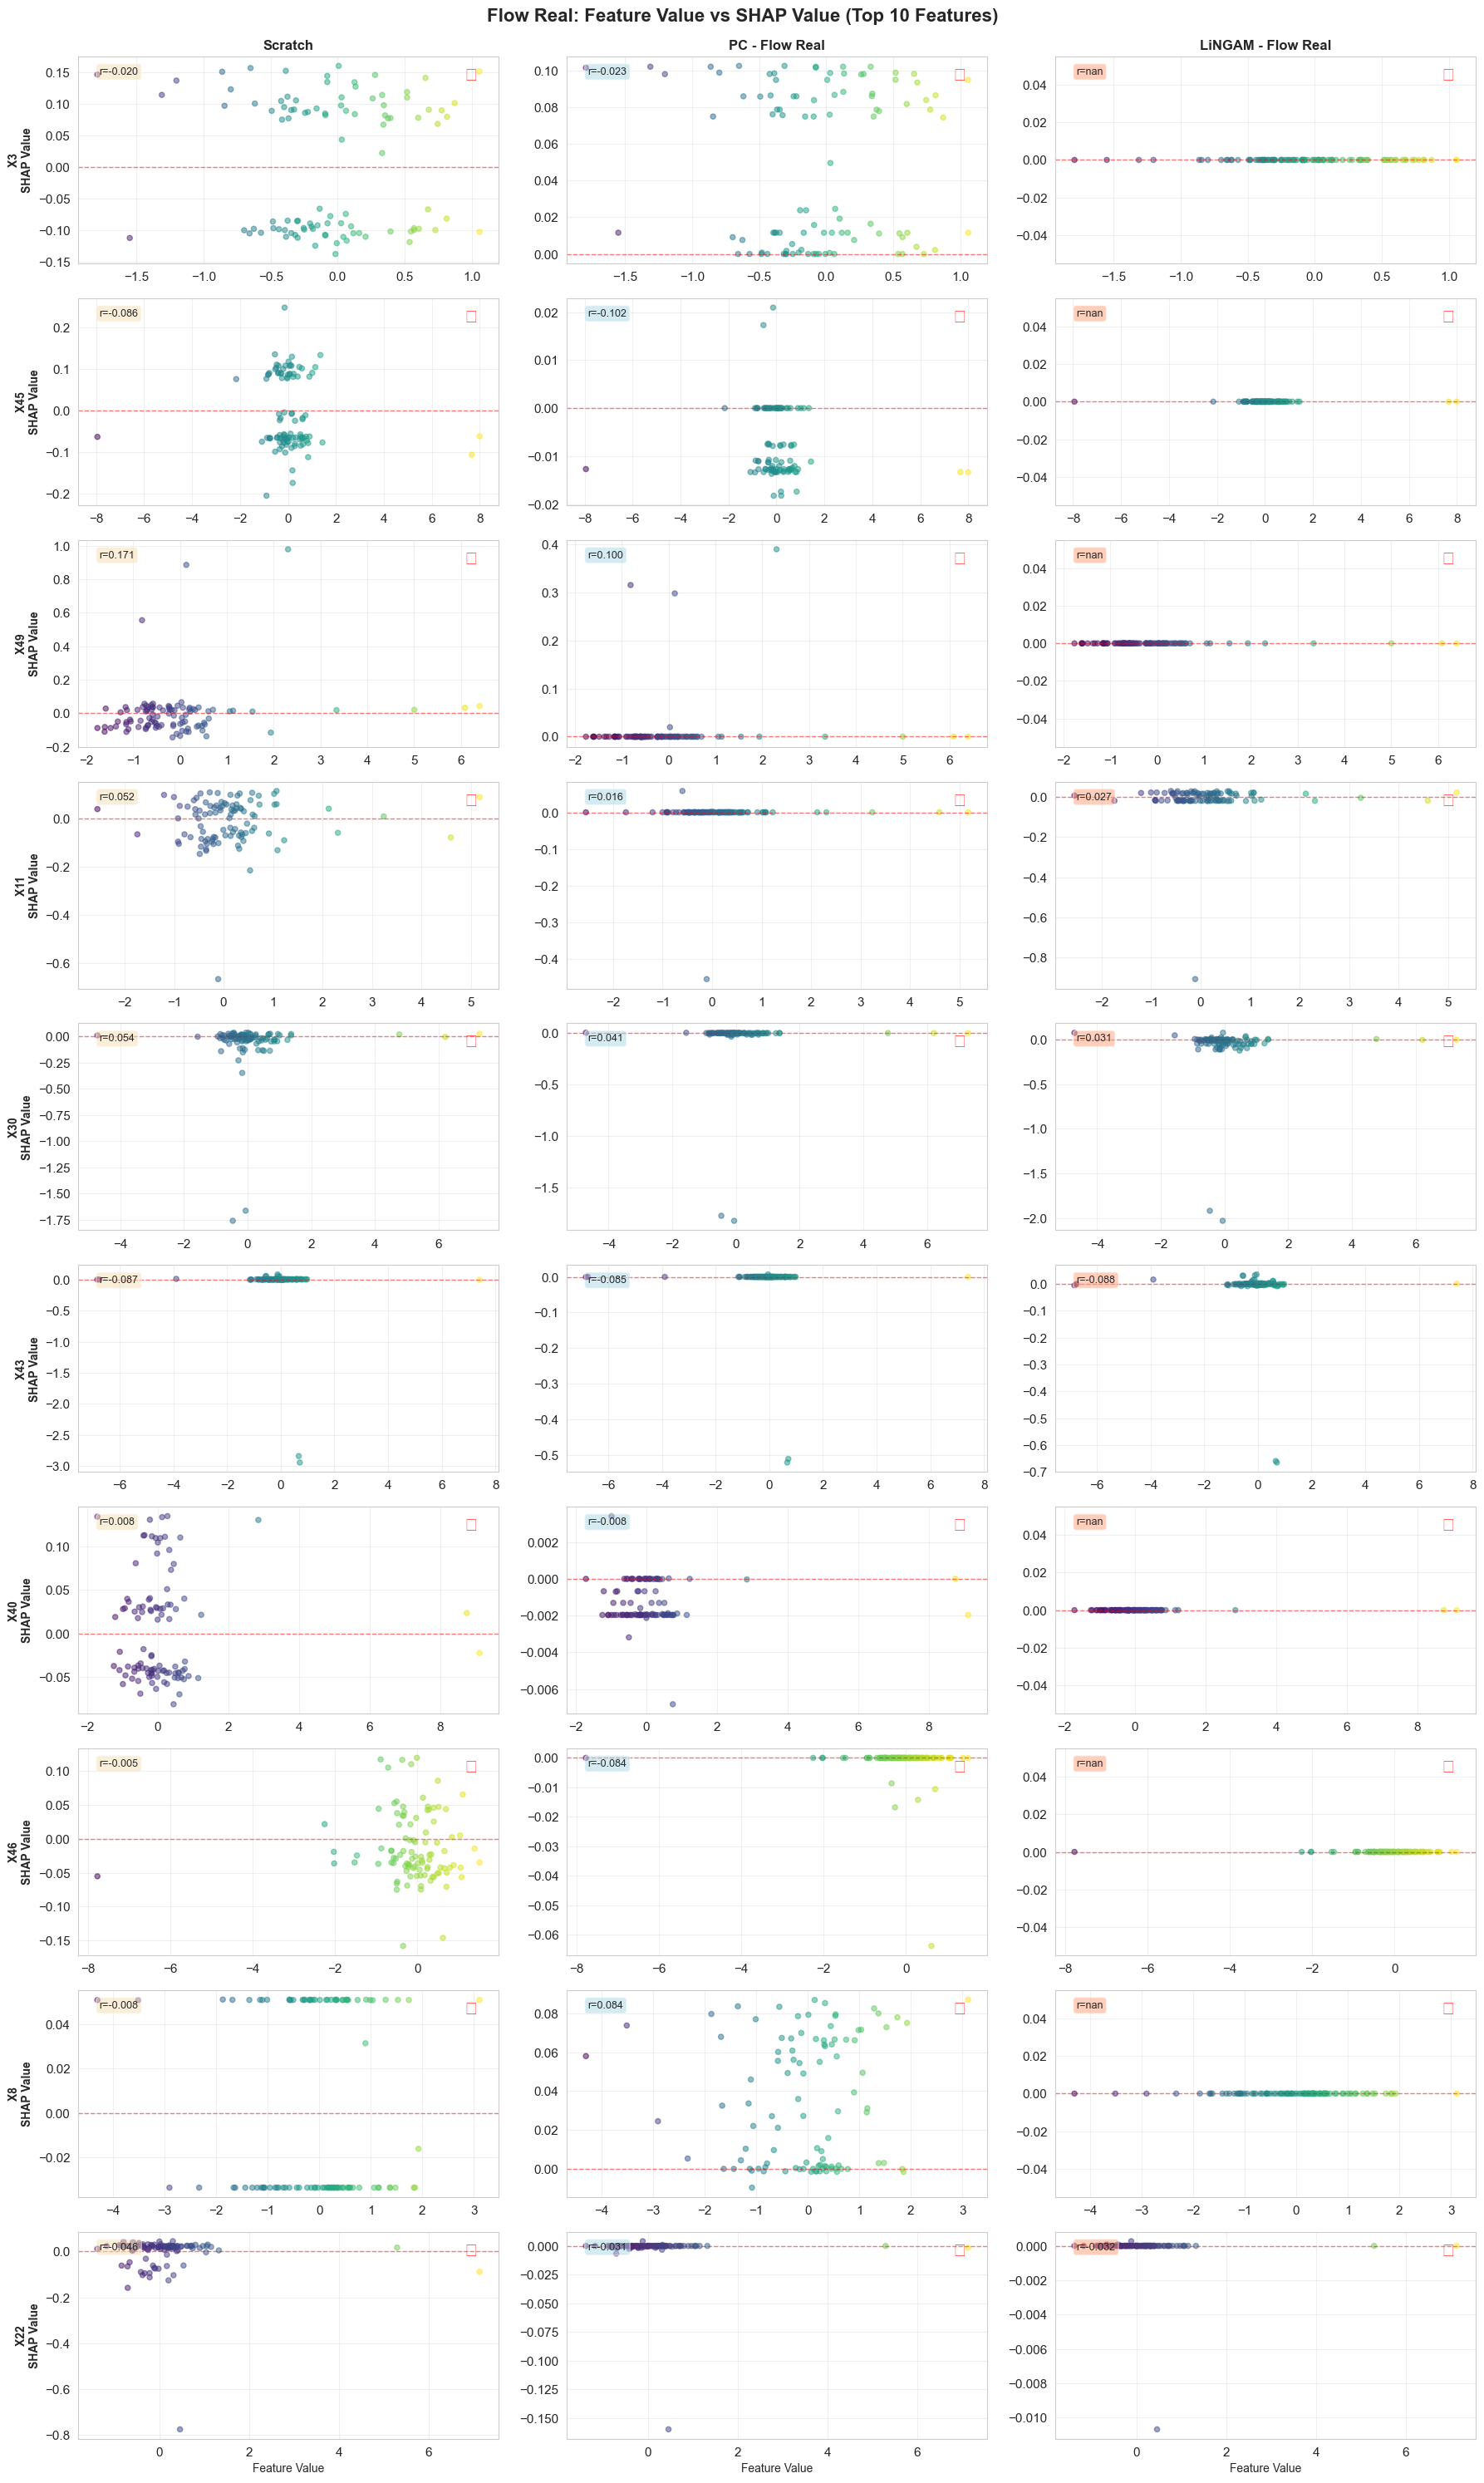

★ = True Y parent
r = Pearson correlation between feature value and SHAP value
Each point represents one test instance


In [38]:
# Create comprehensive dependence plots for Flow Real
# Each row is a feature, columns are: Scratch, PC_Flow_Real, LiNGAM_Flow_Real

fig, axes = plt.subplots(n_features_to_plot, n_cols, figsize=(18, 3*n_features_to_plot))

for feat_idx, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    is_true_parent = idx in true_parents
    
    # Get feature values from test data (to match SHAP values)
    feature_values = X_test_matched.iloc[:, idx].values
    
    # Get SHAP values for this feature
    scratch_shap = scratch_values[:, idx]
    pc_flow_real_shap = pc_flow_real_values[:, idx]
    lingam_flow_real_shap = lingam_flow_real_values[:, idx]
    
    # Plot 1: Scratch
    ax = axes[feat_idx, 0]
    scatter = ax.scatter(feature_values, scratch_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel(f'{fname}\nSHAP Value', fontsize=10, fontweight='bold')
    if feat_idx == 0:
        ax.set_title('Scratch', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_scratch = np.corrcoef(feature_values, scratch_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_scratch:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Mark if true parent
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 2: PC Flow Real
    ax = axes[feat_idx, 1]
    scatter = ax.scatter(feature_values, pc_flow_real_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('PC - Flow Real', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_pc = np.corrcoef(feature_values, pc_flow_real_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_pc:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 3: LiNGAM Flow Real
    ax = axes[feat_idx, 2]
    scatter = ax.scatter(feature_values, lingam_flow_real_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('LiNGAM - Flow Real', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_lingam = np.corrcoef(feature_values, lingam_flow_real_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_lingam:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')

plt.suptitle('Flow Real: Feature Value vs SHAP Value (Top 10 Features)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("r = Pearson correlation between feature value and SHAP value")
print("Each point represents one test instance")

### 14.4 Flow Real: Feature Dependence Plots

### 14.4 Summary of Feature Dependence Analysis

These dependence plots reveal several important insights:

1. **Feature-SHAP Relationships**: The correlation coefficient (r) shows how SHAP values change with feature values
   - Positive r: Higher feature values → Higher SHAP values (positive contribution)
   - Negative r: Higher feature values → Lower SHAP values (negative contribution)
   - Near-zero r: Non-linear or complex relationship

2. **Method Comparison**: 
   - **Scratch** (leftmost column): Standard SHAP without causal structure
   - **PC methods** (middle column): Incorporate causal graph learned via PC algorithm
   - **LiNGAM methods** (rightmost column): Incorporate causal graph learned via LiNGAM

3. **True Parents** (marked with ★):
   - Check if true Y parents show consistent patterns across methods
   - Compare their correlations with non-parent features

4. **Agreement Across Methods**:
   - Similar patterns across columns suggest method robustness
   - Divergent patterns indicate sensitivity to causal graph structure

Precision@K: True Parent Detection
 K  PC_Flow  PC_Flow_Real  LiNGAM_Flow  LiNGAM_Flow_Real
 5 0.600000          1.00         0.60          0.400000
10 0.700000          0.70         0.30          0.400000
15 0.733333          0.60         0.40          0.333333
20 0.700000          0.55         0.45          0.500000
25 0.680000          0.56         0.52          0.520000


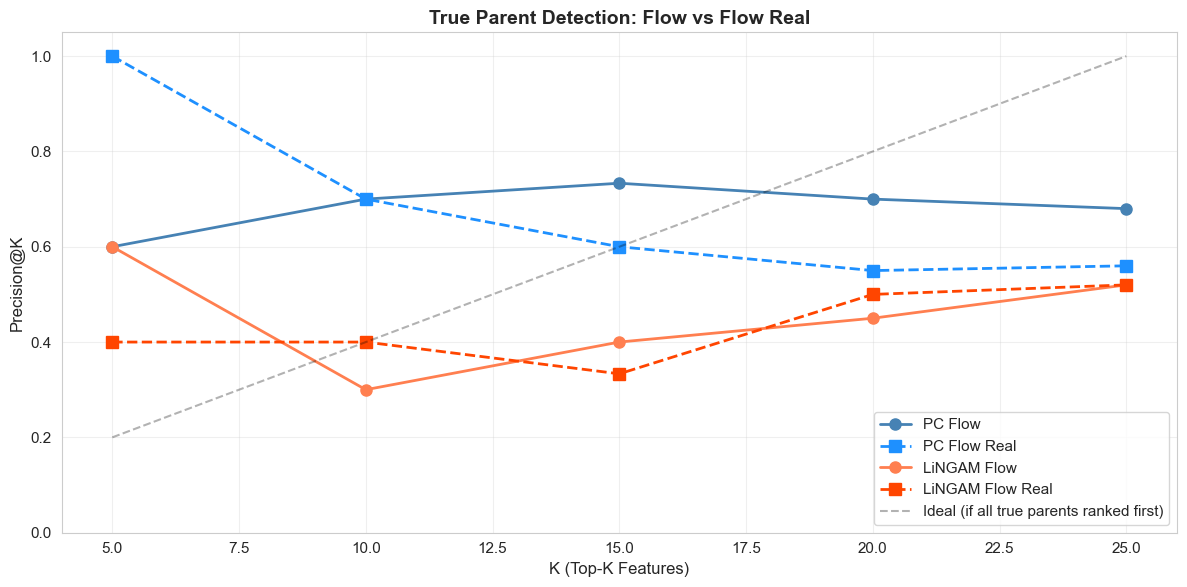


Key Insights:
  - Solid lines = Flow methods
  - Dashed lines = Flow Real methods
  - Higher precision = Better at ranking true parents in top-K


In [39]:
# Precision@K analysis for Flow vs Flow Real
k_values = [5, 10, 15, 20, 25]

precision_data = []

for k in k_values:
    # PC Flow
    top_k_pc_flow = set(np.argsort(pc_flow_importance)[-k:])
    pc_flow_precision = len(top_k_pc_flow & true_parents) / k
    
    # PC Flow Real
    top_k_pc_flow_real = set(np.argsort(pc_flow_real_importance)[-k:])
    pc_flow_real_precision = len(top_k_pc_flow_real & true_parents) / k
    
    # LiNGAM Flow
    top_k_lingam_flow = set(np.argsort(lingam_flow_importance)[-k:])
    lingam_flow_precision = len(top_k_lingam_flow & true_parents) / k
    
    # LiNGAM Flow Real
    top_k_lingam_flow_real = set(np.argsort(lingam_flow_real_importance)[-k:])
    lingam_flow_real_precision = len(top_k_lingam_flow_real & true_parents) / k
    
    precision_data.append({
        'K': k,
        'PC_Flow': pc_flow_precision,
        'PC_Flow_Real': pc_flow_real_precision,
        'LiNGAM_Flow': lingam_flow_precision,
        'LiNGAM_Flow_Real': lingam_flow_real_precision,
    })

precision_df = pd.DataFrame(precision_data)

print("Precision@K: True Parent Detection")
print("="*80)
print(precision_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

x = precision_df['K']
ax.plot(x, precision_df['PC_Flow'], marker='o', linewidth=2, markersize=8, label='PC Flow', color='steelblue')
ax.plot(x, precision_df['PC_Flow_Real'], marker='s', linewidth=2, markersize=8, label='PC Flow Real', color='dodgerblue', linestyle='--')
ax.plot(x, precision_df['LiNGAM_Flow'], marker='o', linewidth=2, markersize=8, label='LiNGAM Flow', color='coral')
ax.plot(x, precision_df['LiNGAM_Flow_Real'], marker='s', linewidth=2, markersize=8, label='LiNGAM Flow Real', color='orangered', linestyle='--')

# Add ideal line (50% of features are true parents)
ideal_precision = [min(k / len(true_parents), 1.0) for k in k_values]
ax.plot(x, ideal_precision, 'k--', alpha=0.3, label='Ideal (if all true parents ranked first)')

ax.set_xlabel('K (Top-K Features)', fontsize=12)
ax.set_ylabel('Precision@K', fontsize=12)
ax.set_title('True Parent Detection: Flow vs Flow Real', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("  - Solid lines = Flow methods")
print("  - Dashed lines = Flow Real methods")
print("  - Higher precision = Better at ranking true parents in top-K")

### 15.4 Performance Comparison: Flow vs Flow Real

Comparing how well Flow and Flow Real identify true parent features.

### 15.3 Instance-Level Correlation: Flow vs Flow Real

Instance-Level SHAP Value Correlations (Flow vs Flow Real)
PC Discovery:
  - Pearson correlation:  0.1547
  - Spearman correlation: 0.1795

LiNGAM Discovery:
  - Pearson correlation:  0.2669
  - Spearman correlation: 0.0535


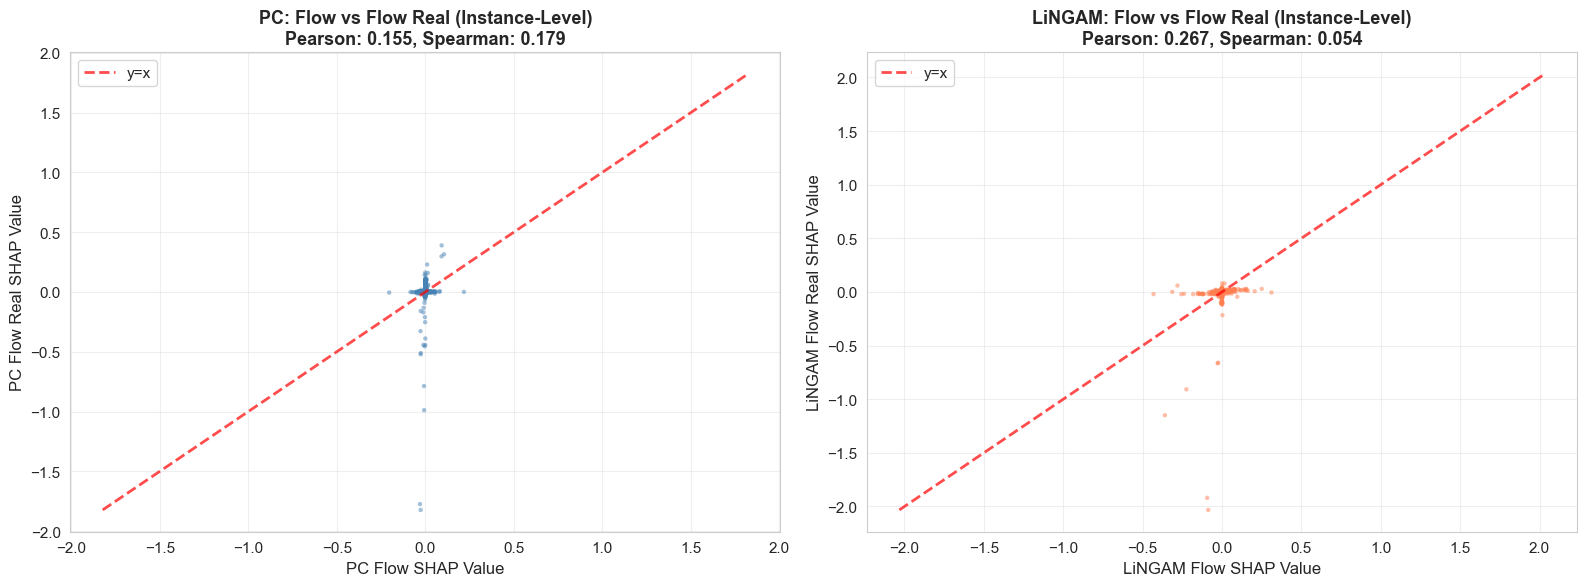


Note: Scatter plot with subsampled points for clarity
Showing 5,000 sampled points out of 5,000 total


In [40]:
# Compare instance-level SHAP values between Flow and Flow Real
pc_flow_flat = pc_flow_values.flatten()
pc_flow_real_flat = pc_flow_real_values.flatten()
lingam_flow_flat = lingam_flow_values.flatten()
lingam_flow_real_flat = lingam_flow_real_values.flatten()

# Calculate correlations
pc_pearson, _ = pearsonr(pc_flow_flat, pc_flow_real_flat)
pc_spearman, _ = spearmanr(pc_flow_flat, pc_flow_real_flat)
lingam_pearson, _ = pearsonr(lingam_flow_flat, lingam_flow_real_flat)
lingam_spearman, _ = spearmanr(lingam_flow_flat, lingam_flow_real_flat)

print("Instance-Level SHAP Value Correlations (Flow vs Flow Real)")
print("="*80)
print(f"PC Discovery:")
print(f"  - Pearson correlation:  {pc_pearson:.4f}")
print(f"  - Spearman correlation: {pc_spearman:.4f}")
print(f"\nLiNGAM Discovery:")
print(f"  - Pearson correlation:  {lingam_pearson:.4f}")
print(f"  - Spearman correlation: {lingam_spearman:.4f}")

# Visualize with scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subsample for visualization (too many points otherwise)
n_samples_plot = min(5000, len(pc_flow_flat))
sample_indices = np.random.choice(len(pc_flow_flat), n_samples_plot, replace=False)

# PC scatter
axes[0].scatter(pc_flow_flat[sample_indices], pc_flow_real_flat[sample_indices], 
                alpha=0.5, s=10, c='steelblue', edgecolors='none')
max_val_pc = max(np.abs(pc_flow_flat[sample_indices]).max(), np.abs(pc_flow_real_flat[sample_indices]).max())
axes[0].plot([-max_val_pc, max_val_pc], [-max_val_pc, max_val_pc], 'r--', alpha=0.7, linewidth=2, label='y=x')
axes[0].set_xlabel('PC Flow SHAP Value', fontsize=12)
axes[0].set_ylabel('PC Flow Real SHAP Value', fontsize=12)
axes[0].set_title(f'PC: Flow vs Flow Real (Instance-Level)\nPearson: {pc_pearson:.3f}, Spearman: {pc_spearman:.3f}', 
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LiNGAM scatter
axes[1].scatter(lingam_flow_flat[sample_indices], lingam_flow_real_flat[sample_indices], 
                alpha=0.5, s=10, c='coral', edgecolors='none')
max_val_lingam = max(np.abs(lingam_flow_flat[sample_indices]).max(), np.abs(lingam_flow_real_flat[sample_indices]).max())
axes[1].plot([-max_val_lingam, max_val_lingam], [-max_val_lingam, max_val_lingam], 'r--', alpha=0.7, linewidth=2, label='y=x')
axes[1].set_xlabel('LiNGAM Flow SHAP Value', fontsize=12)
axes[1].set_ylabel('LiNGAM Flow Real SHAP Value', fontsize=12)
axes[1].set_title(f'LiNGAM: Flow vs Flow Real (Instance-Level)\nPearson: {lingam_pearson:.3f}, Spearman: {lingam_spearman:.3f}', 
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Scatter plot with subsampled points for clarity")
print(f"Showing {n_samples_plot:,} sampled points out of {len(pc_flow_flat):,} total")

### 15.2 Difference Analysis: Which Features Diverge Most?

TOP 10 FEATURES WITH LARGEST FLOW vs FLOW REAL DIFFERENCES

PC Discovery:
--------------------------------------------------------------------------------
Rank   Feature  Idx   Flow       Flow_Real  Diff       True Parent
--------------------------------------------------------------------------------
1      X3       3     0.0011     0.0487     0.0476     ✓
2      X30      30    0.0017     0.0387     0.0370     ✓
3      X8       8     0.0009     0.0349     0.0341     ✓
4      X48      48    0.0007     0.0203     0.0196     ✓
5      X17      17    0.0130     0.0003     0.0127     ✓
6      X4       4     0.0127     0.0006     0.0121     
7      X12      12    0.0007     0.0114     0.0107     ✓
8      X43      43    0.0010     0.0104     0.0094     
9      X24      24    0.0165     0.0082     0.0083     
10     X37      37    0.0004     0.0082     0.0078     


LiNGAM Discovery:
--------------------------------------------------------------------------------
Rank   Feature  Idx   Flow    

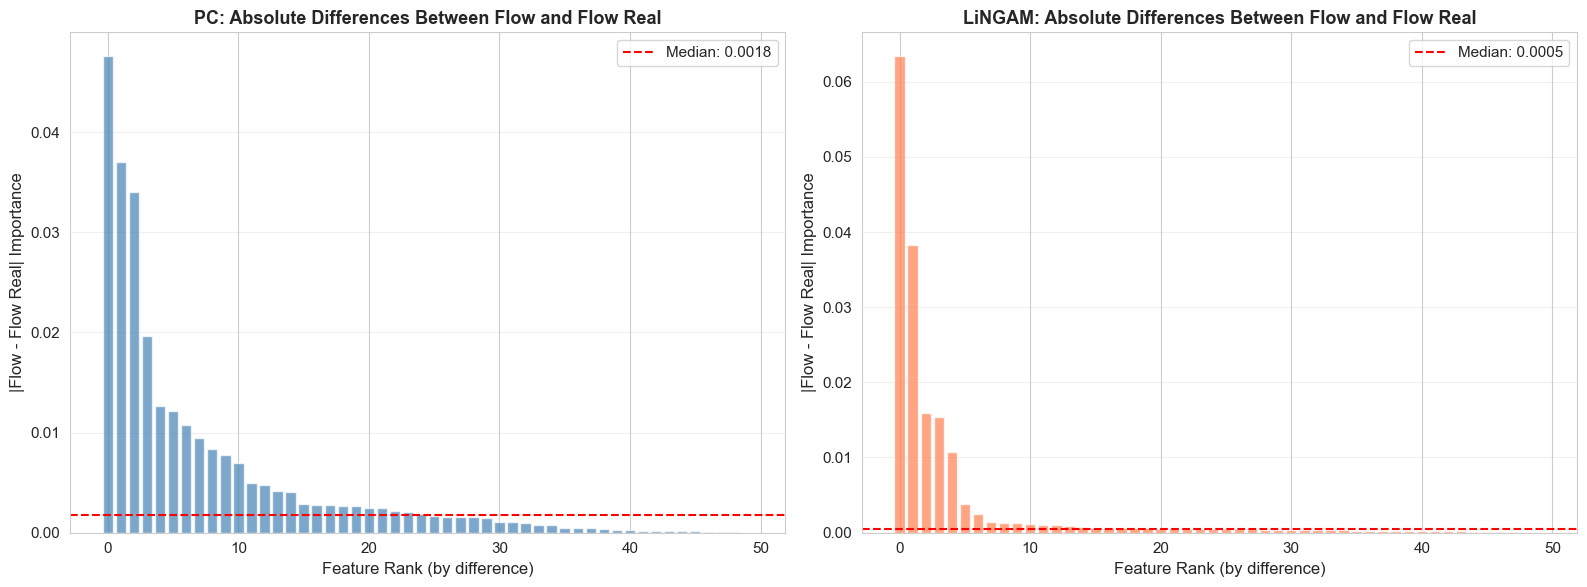


Summary Statistics:
  PC   - Mean difference: 0.0053, Median: 0.0018, Max: 0.0476
  LiNGAM - Mean difference: 0.0034, Median: 0.0005, Max: 0.0634


In [41]:
# Calculate absolute differences between Flow and Flow Real
pc_diff = np.abs(pc_flow_importance - pc_flow_real_importance)
lingam_diff = np.abs(lingam_flow_importance - lingam_flow_real_importance)

# Get top 10 features with largest differences
top_10_diff_pc = np.argsort(pc_diff)[-10:][::-1]
top_10_diff_lingam = np.argsort(lingam_diff)[-10:][::-1]

print("TOP 10 FEATURES WITH LARGEST FLOW vs FLOW REAL DIFFERENCES")
print("="*80)

print("\nPC Discovery:")
print("-"*80)
print(f"{'Rank':<6} {'Feature':<8} {'Idx':<5} {'Flow':<10} {'Flow_Real':<10} {'Diff':<10} {'True Parent'}")
print("-"*80)
for rank, idx in enumerate(top_10_diff_pc, 1):
    fname = feature_names[idx]
    is_parent = "✓" if idx in true_parents else ""
    print(f"{rank:<6} {fname:<8} {idx:<5} {pc_flow_importance[idx]:<10.4f} {pc_flow_real_importance[idx]:<10.4f} {pc_diff[idx]:<10.4f} {is_parent}")

print("\n" + "="*80)
print("\nLiNGAM Discovery:")
print("-"*80)
print(f"{'Rank':<6} {'Feature':<8} {'Idx':<5} {'Flow':<10} {'Flow_Real':<10} {'Diff':<10} {'True Parent'}")
print("-"*80)
for rank, idx in enumerate(top_10_diff_lingam, 1):
    fname = feature_names[idx]
    is_parent = "✓" if idx in true_parents else ""
    print(f"{rank:<6} {fname:<8} {idx:<5} {lingam_flow_importance[idx]:<10.4f} {lingam_flow_real_importance[idx]:<10.4f} {lingam_diff[idx]:<10.4f} {is_parent}")

# Visualize differences
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC differences
axes[0].bar(range(len(pc_diff)), sorted(pc_diff, reverse=True), alpha=0.7, color='steelblue')
axes[0].set_xlabel('Feature Rank (by difference)', fontsize=12)
axes[0].set_ylabel('|Flow - Flow Real| Importance', fontsize=12)
axes[0].set_title('PC: Absolute Differences Between Flow and Flow Real', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=np.median(pc_diff), color='red', linestyle='--', label=f'Median: {np.median(pc_diff):.4f}')
axes[0].legend()

# LiNGAM differences
axes[1].bar(range(len(lingam_diff)), sorted(lingam_diff, reverse=True), alpha=0.7, color='coral')
axes[1].set_xlabel('Feature Rank (by difference)', fontsize=12)
axes[1].set_ylabel('|Flow - Flow Real| Importance', fontsize=12)
axes[1].set_title('LiNGAM: Absolute Differences Between Flow and Flow Real', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=np.median(lingam_diff), color='red', linestyle='--', label=f'Median: {np.median(lingam_diff):.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Summary Statistics:")
print(f"  PC   - Mean difference: {pc_diff.mean():.4f}, Median: {np.median(pc_diff):.4f}, Max: {pc_diff.max():.4f}")
print(f"  LiNGAM - Mean difference: {lingam_diff.mean():.4f}, Median: {np.median(lingam_diff):.4f}, Max: {lingam_diff.max():.4f}")

### 15.1 Scatter Plots: Flow vs Flow Real

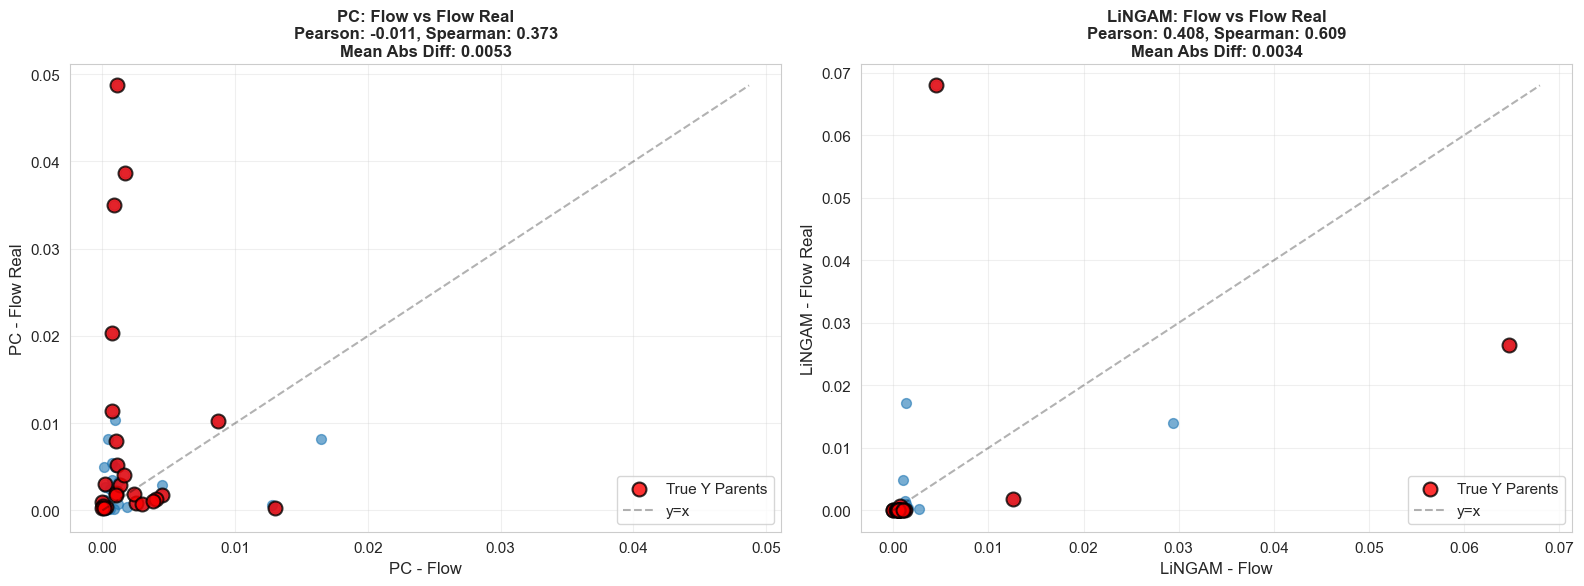

Key insights:
  - Closer points to diagonal = Higher agreement between Flow and Flow Real
  - Red points = True Y parents


In [42]:
# Compare Flow vs Flow Real for PC and LiNGAM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comparisons = [
    ('PC', pc_flow_importance, pc_flow_real_importance),
    ('LiNGAM', lingam_flow_importance, lingam_flow_real_importance)
]

for ax, (method_name, flow_imp, flow_real_imp) in zip(axes, comparisons):
    # Scatter plot
    ax.scatter(flow_imp, flow_real_imp, alpha=0.6, s=50)
    
    # Highlight true parents
    true_parent_mask = [i in true_parents for i in range(len(flow_imp))]
    ax.scatter(flow_imp[true_parent_mask], flow_real_imp[true_parent_mask], 
               alpha=0.8, s=100, c='red', label='True Y Parents', edgecolors='black', linewidths=1.5)
    
    # Add diagonal line
    max_val = max(flow_imp.max(), flow_real_imp.max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='y=x')
    
    # Calculate correlations
    pearson_corr, _ = pearsonr(flow_imp, flow_real_imp)
    spearman_corr, _ = spearmanr(flow_imp, flow_real_imp)
    
    # Calculate mean absolute difference
    mean_diff = np.abs(flow_imp - flow_real_imp).mean()
    
    ax.set_xlabel(f'{method_name} - Flow', fontsize=12)
    ax.set_ylabel(f'{method_name} - Flow Real', fontsize=12)
    ax.set_title(f'{method_name}: Flow vs Flow Real\nPearson: {pearson_corr:.3f}, Spearman: {spearman_corr:.3f}\nMean Abs Diff: {mean_diff:.4f}', 
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insights:")
print(f"  - Closer points to diagonal = Higher agreement between Flow and Flow Real")
print(f"  - Red points = True Y parents")

## 15. Flow vs Flow Real: Direct Comparison

This section analyzes the differences between **Flow** and **Flow Real** methods for both PC and LiNGAM discovery algorithms. We examine:
- Feature importance correlations
- Instance-level agreement  
- Ranking differences
- Which features show the most divergence between Flow and Flow Real